# Control policy optimization

In this example, a symbolic policy is evolved for the pendulum swingup task. Gymnax is used for simulation of the pendulum environment, showing that Kozax can easily be extended to external libraries.

In [ ]:
!pip install mujoco
!pip install mujoco_mjx
!pip install brax
!pip install playground
!pip install kozax
!pip install gymnax
!pip install jaxtyping
!pip install playground warp-lang==1.12.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.4/7.4 MB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 243.5/243.5 kB 11.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 71.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 741.0/741.0 kB 62.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 356.9/356.9 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.4/172.4 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 10.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 10.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 138.7/138.7 MB 7.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 103.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.1/

In [ ]:
# @title Check if MuJoCo installation was successful

import distutils.util
import os
import subprocess

if subprocess.run('nvidia-smi').returncode:
  raise RuntimeError(
      'Cannot communicate with GPU. '
      'Make sure you are using a GPU Colab runtime. '
      'Go to the Runtime menu and select Choose runtime type.'
  )

# Add an ICD config so that glvnd can pick up the Nvidia EGL driver.
# This is usually installed as part of an Nvidia driver package, but the Colab
# kernel doesn't install its driver via APT, and as a result the ICD is missing.
# (https://github.com/NVIDIA/libglvnd/blob/master/src/EGL/icd_enumeration.md)
NVIDIA_ICD_CONFIG_PATH = '/usr/share/glvnd/egl_vendor.d/10_nvidia.json'
if not os.path.exists(NVIDIA_ICD_CONFIG_PATH):
  with open(NVIDIA_ICD_CONFIG_PATH, 'w') as f:
    f.write("""{
    "file_format_version" : "1.0.0",
    "ICD" : {
        "library_path" : "libEGL_nvidia.so.0"
    }
}
""")

# Configure MuJoCo to use the EGL rendering backend (requires GPU)
print('Setting environment variable to use GPU rendering:')
%env MUJOCO_GL=egl

try:
  print('Checking that the installation succeeded:')
  import mujoco

  mujoco.MjModel.from_xml_string('<mujoco/>')
except Exception as e:
  raise e from RuntimeError(
      'Something went wrong during installation. Check the shell output above '
      'for more information.\n'
      'If using a hosted Colab runtime, make sure you enable GPU acceleration '
      'by going to the Runtime menu and selecting "Choose runtime type".'
  )

print('Installation successful.')

# Tell XLA to use Triton GEMM, this improves steps/sec by ~30% on some GPUs
xla_flags = os.environ.get('XLA_FLAGS', '')
xla_flags += ' --xla_gpu_triton_gemm_any=True'
os.environ['XLA_FLAGS'] = xla_flags

Setting environment variable to use GPU rendering:
env: MUJOCO_GL=egl
Checking that the installation succeeded:
Installation successful.


In [ ]:
# @title Import packages for plotting and creating graphics
import itertools
import time
from typing import Callable, List, NamedTuple, Optional, Union
import numpy as np

# Graphics and plotting.
print("Installing mediapy:")
!command -v ffmpeg >/dev/null || (apt update && apt install -y ffmpeg)
!pip install -q mediapy
import mediapy as media
import matplotlib.pyplot as plt

# More legible printing from numpy.
np.set_printoptions(precision=3, suppress=True, linewidth=100)

Installing mediapy:


In [ ]:
# @title Import MuJoCo, MJX, and Brax
from datetime import datetime
import functools
import os
from typing import Any, Dict, Sequence, Tuple, Union
from brax import base
from brax import envs
from brax import math
from brax.base import Base, Motion, Transform
from brax.base import State as PipelineState
from brax.envs.base import Env, PipelineEnv, State
from brax.io import html, mjcf, model
from brax.mjx.base import State as MjxState
from brax.training.agents.ppo import networks as ppo_networks
from brax.training.agents.ppo import train as ppo
from brax.training.agents.sac import networks as sac_networks
from brax.training.agents.sac import train as sac
from etils import epath
from flax import struct
from flax.training import orbax_utils
from IPython.display import HTML, clear_output
import jax
import jax.numpy as jnp
import jax.random as jr
from matplotlib import pyplot as plt
import mediapy as media
from ml_collections import config_dict
import mujoco
from mujoco import mjx
import numpy as np
from orbax import checkpoint as ocp

In [ ]:
from mujoco_playground import registry

class MujocoGymnaxWrapper:

    def __init__(self, env_name = None, env_instance = None, config_overrides = None):
        if env_instance is not None:
            self.env = env_instance
        else:
            self.env = registry.load(env_name)
        # self.observation_space = self.env.observation_size
        self.action_space = self.env.action_size

    # state, env_state = self.env.reset(subkey, self.env_params)

    def reset(self, key, params=None):
        #state consists of pipeline_state, obs, reward, done, metrics, info
        state = self.env.reset(key)
        return state.obs, state

     # next_state, next_env_state, reward, done, _ = self.env.step(
     #            subkey, env_state, action, self.env_params
     #        )

    def step(self, key, state, action, params=None):

      next_state = self.env.step(state, action)

      done = next_state.done
      obs = next_state.obs
      reward = next_state.reward

      return obs, next_state, reward, done, {}

    def render(self, rollout, camera = None):
      if camera == None:
        return self.env.render(rollout)
      else:
        return self.env.render(rollout, camera=camera)

    @property
    def dt(self):
        return self.env.dt

In [ ]:
def compute_trajectory_py(key, env, policy, T=1000, stride=1):
  jit_reset = jax.jit(env.reset)
  jit_step = jax.jit(env.step)
  obs, env_state = jit_reset(key)
  states = []

  for t in range(T):
      action = policy(obs)
      obs, env_state, reward, done, _ = jit_step(key, env_state, action)

      if t % stride == 0:
          states.append(env_state)

      if done:
          break

  return states

In [ ]:
def repeated_evaluation(key, policy, env):
    def single_run(key):
        obs, env_state = env.reset(key)

        def step_fn(carry, t):
            obs, env_state, done, key = carry
            key, subkey = jr.split(key)
            action = policy(obs)
            obs, env_state, reward, done_new, _ = env.step(subkey, env_state, action, None)
            done = done | done_new.astype(bool)
            reward = jnp.where(done, 0.0, reward)
            return (obs, env_state, done, key), (obs, reward, action, done)

        (_, _, _, _), (_, treward, _, _) = jax.lax.scan(
            step_fn,
            (obs, env_state, False, key),
            jnp.arange(T)
        )
        return jnp.sum(treward)

    keys = jr.split(key, 10)
    return jax.vmap(single_run)(keys)

## Cartpole

Action Space: [-1, 1], where action represents the numerical force applied to the cart

Observation Space: $ℝ^{4}$

0.   car_position
1.   vertical_angle_pole
2.   linear_velocity_cart
3.   angular_velocity_pole

Reward: +1 is awarded for each timestep that the pole is upright.

The episode terminates when episode duration reaches 1000 timestep or the absolute value of the vertical angle between the pole and the cart is greater than 0.2 radians.

### Visualize best solution

In [ ]:
mujoco_env = MujocoGymnaxWrapper('CartpoleBalance')
T = 1000

Warp 1.12.1 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "Tesla T4" (15 GiB, sm_75, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.12.1
Warp DeprecationWarning: The symbol `warp.types.warp_type_to_np_dtype` will soon be removed from the public API. It can still be accessed from `warp._src.types.warp_type_to_np_dtype` but might be changed or removed without notice.


### Complexity 7, equation [0.1*y0+y1+y1]

In [ ]:
policy = lambda obs: jnp.tanh(jnp.array([0.1*obs[0]+obs[1]+obs[1]])) # 0.1*y0+y1+y1

Timestep 0 : Cart position: -0.010109133087098598 | Cart velocity: -0.011163855902850628 | Pole angle: -0.008137214928865433
Timestep 50 : Cart position: 0.04909240081906319 | Cart velocity: 0.043814241886138916 | Pole angle: -0.006217863876372576
Timestep 100 : Cart position: 0.08977965265512466 | Cart velocity: -0.011058719828724861 | Pole angle: -0.006810574326664209
Timestep 150 : Cart position: 0.008266100659966469 | Cart velocity: -0.04834490269422531 | Pole angle: -0.0005735571030527353
Timestep 200 : Cart position: -0.028391947969794273 | Cart velocity: 0.02411133237183094 | Pole angle: 0.0024603907950222492
Timestep 250 : Cart position: 0.0732978880405426 | Cart velocity: 0.055122558027505875 | Pole angle: -0.004193601664155722
Timestep 300 : Cart position: 0.09985441714525223 | Cart velocity: -0.03659803047776222 | Pole angle: -0.0062928092665970325
Timestep 350 : Cart position: -0.024734552949666977 | Cart velocity: -0.05883316323161125 | Pole angle: 0.0020360159687697887
Ti

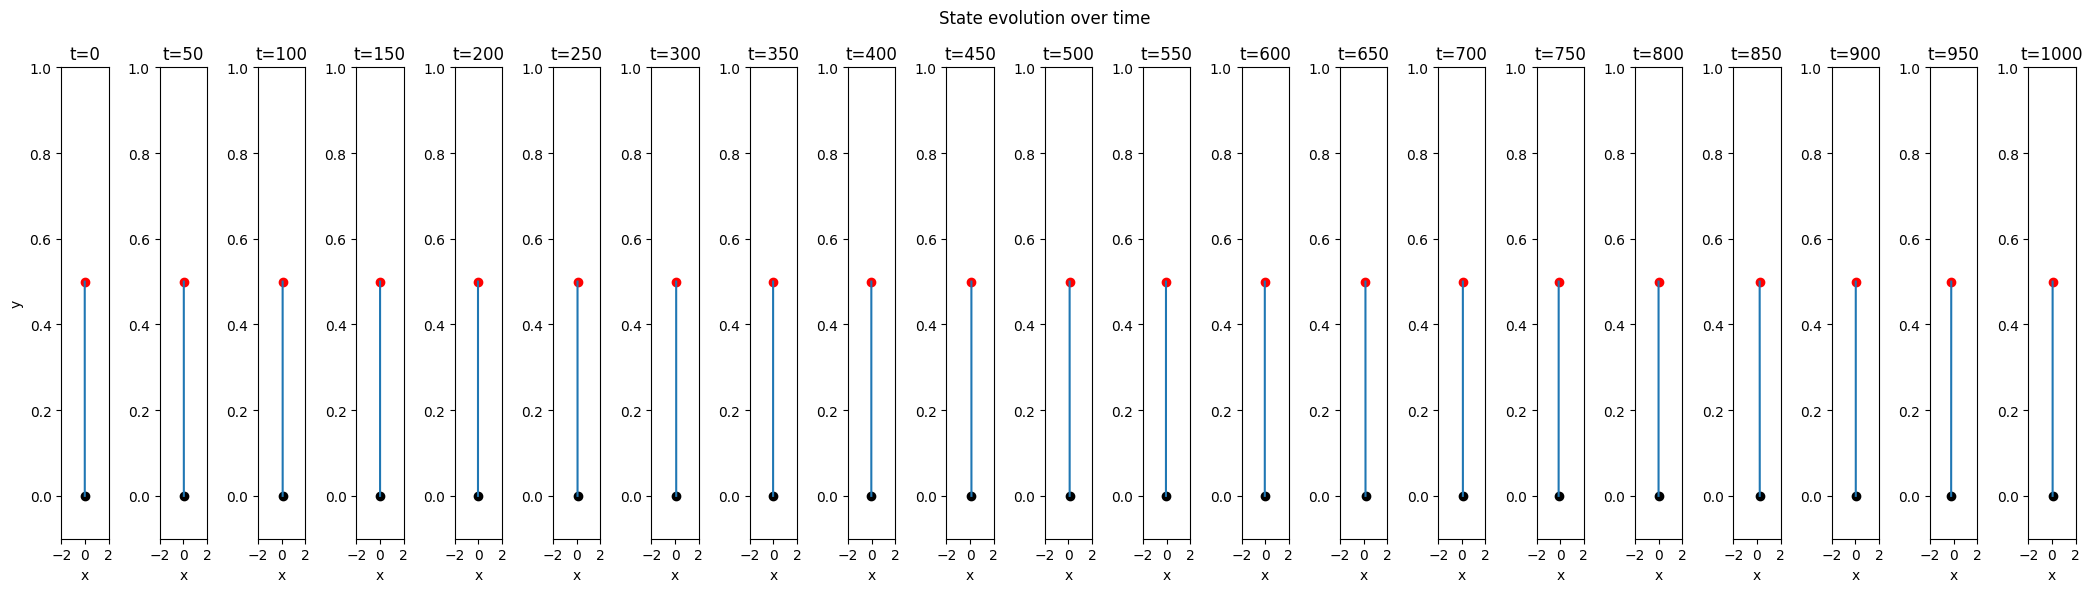

Total reward: 1000.0


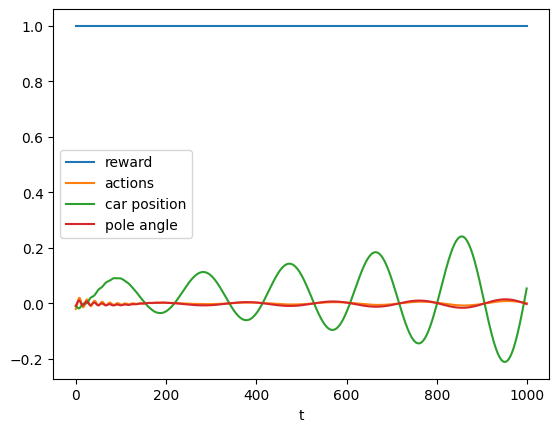

In [ ]:
# Key 0 (fitness = 1000)
key = jax.random.PRNGKey(0)
obs, env_state = env.reset(key)
compute_and_visualize(obs, env_state, policy, T)

Timestep 0 : Cart position: -0.0010177891235798597 | Cart velocity: 0.0021478678099811077 | Pole angle: -0.0022742089349776506
Timestep 50 : Cart position: 0.04697173833847046 | Cart velocity: 0.03258389234542847 | Pole angle: -0.00358471623621881
Timestep 100 : Cart position: 0.07406885176897049 | Cart velocity: -0.011479477398097515 | Pole angle: -0.004844922572374344
Timestep 150 : Cart position: 0.011404032818973064 | Cart velocity: -0.035610996186733246 | Pole angle: -0.0004408227978274226
Timestep 200 : Cart position: -0.010975882411003113 | Cart velocity: 0.02050136774778366 | Pole angle: 0.0013612130424007773
Timestep 250 : Cart position: 0.06655482202768326 | Cart velocity: 0.039379823952913284 | Pole angle: -0.0037729765754193068
Timestep 300 : Cart position: 0.08031480014324188 | Cart velocity: -0.030371401458978653 | Pole angle: -0.004947556182742119
Timestep 350 : Cart position: -0.013589777052402496 | Cart velocity: -0.0414881557226181 | Pole angle: 0.0013476407621055841


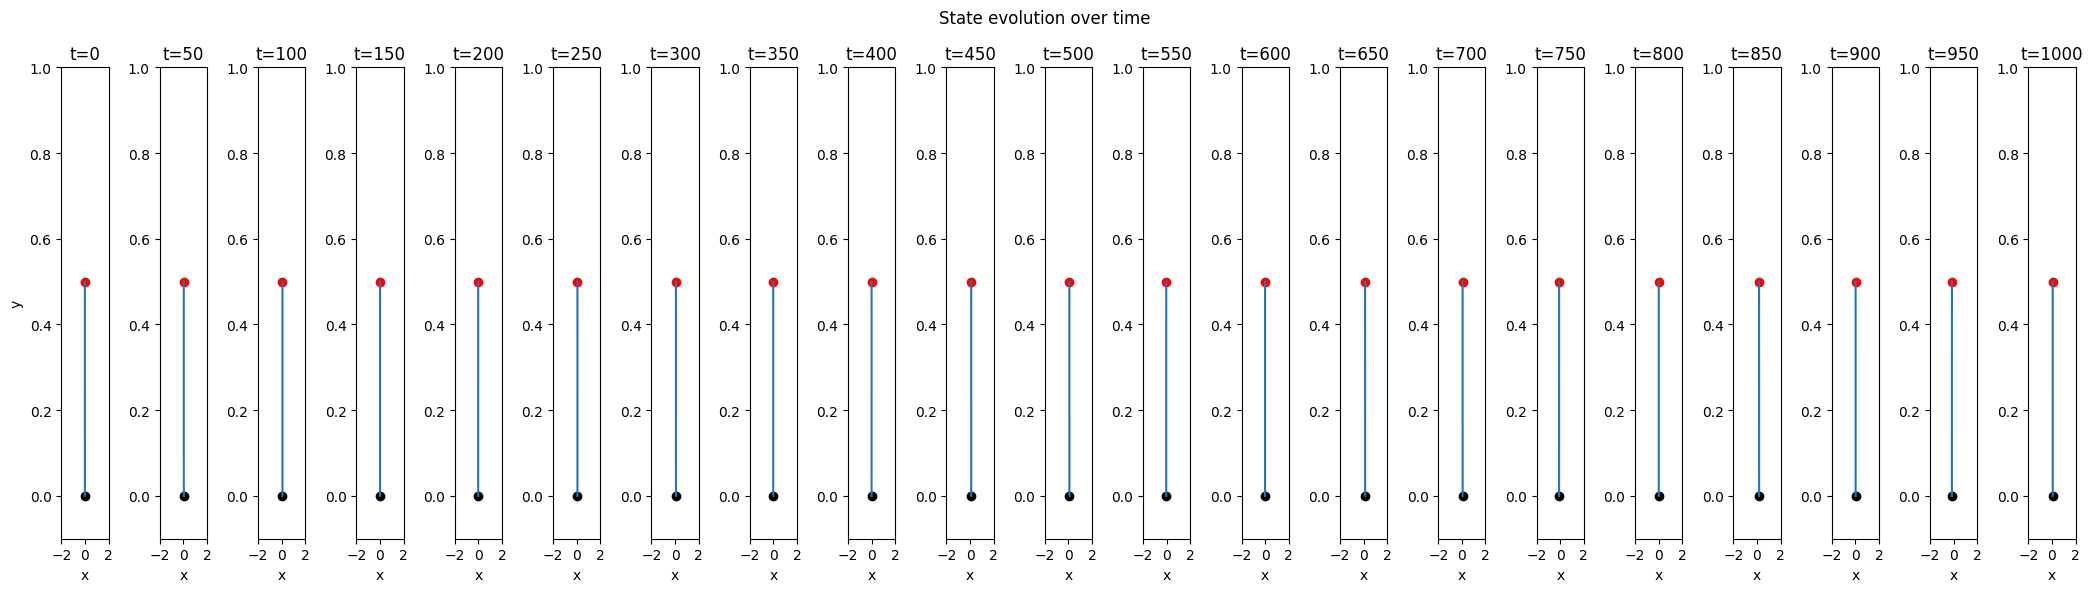

Total reward: 1000.0


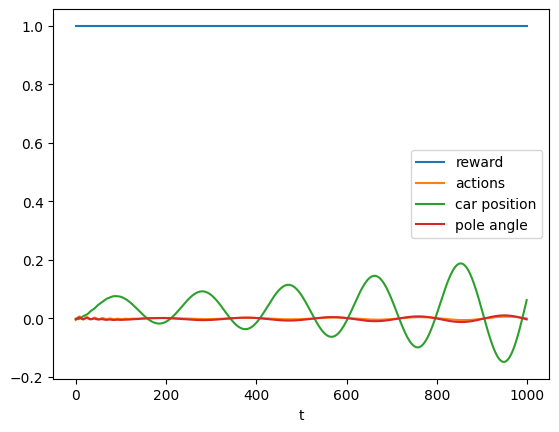

In [ ]:
# Key 26 (fitness = 1000)
key = jax.random.PRNGKey(26)
obs, env_state = env.reset(key)
compute_and_visualize(obs, env_state, policy, T)

Timestep 0 : Cart position: -0.009695615619421005 | Cart velocity: -0.010546131059527397 | Pole angle: -0.0006659762584604323
Timestep 50 : Cart position: 0.020988093689084053 | Cart velocity: 0.041824910789728165 | Pole angle: -0.0012671303702518344
Timestep 100 : Cart position: 0.08748169988393784 | Cart velocity: 0.011609074659645557 | Pole angle: -0.005441160872578621
Timestep 150 : Cart position: 0.039466191083192825 | Cart velocity: -0.04816074296832085 | Pole angle: -0.002294018166139722
Timestep 200 : Cart position: -0.031583864241838455 | Cart velocity: -0.004482892341911793 | Pole angle: 0.0026900838129222393
Timestep 250 : Cart position: 0.036679111421108246 | Cart velocity: 0.05820198357105255 | Pole angle: -0.0016799252480268478
Timestep 300 : Cart position: 0.10952325165271759 | Cart velocity: -0.003993772901594639 | Pole angle: -0.006819186266511679
Timestep 350 : Cart position: 0.016958337277173996 | Cart velocity: -0.068084716796875 | Pole angle: -0.0008089545299299061

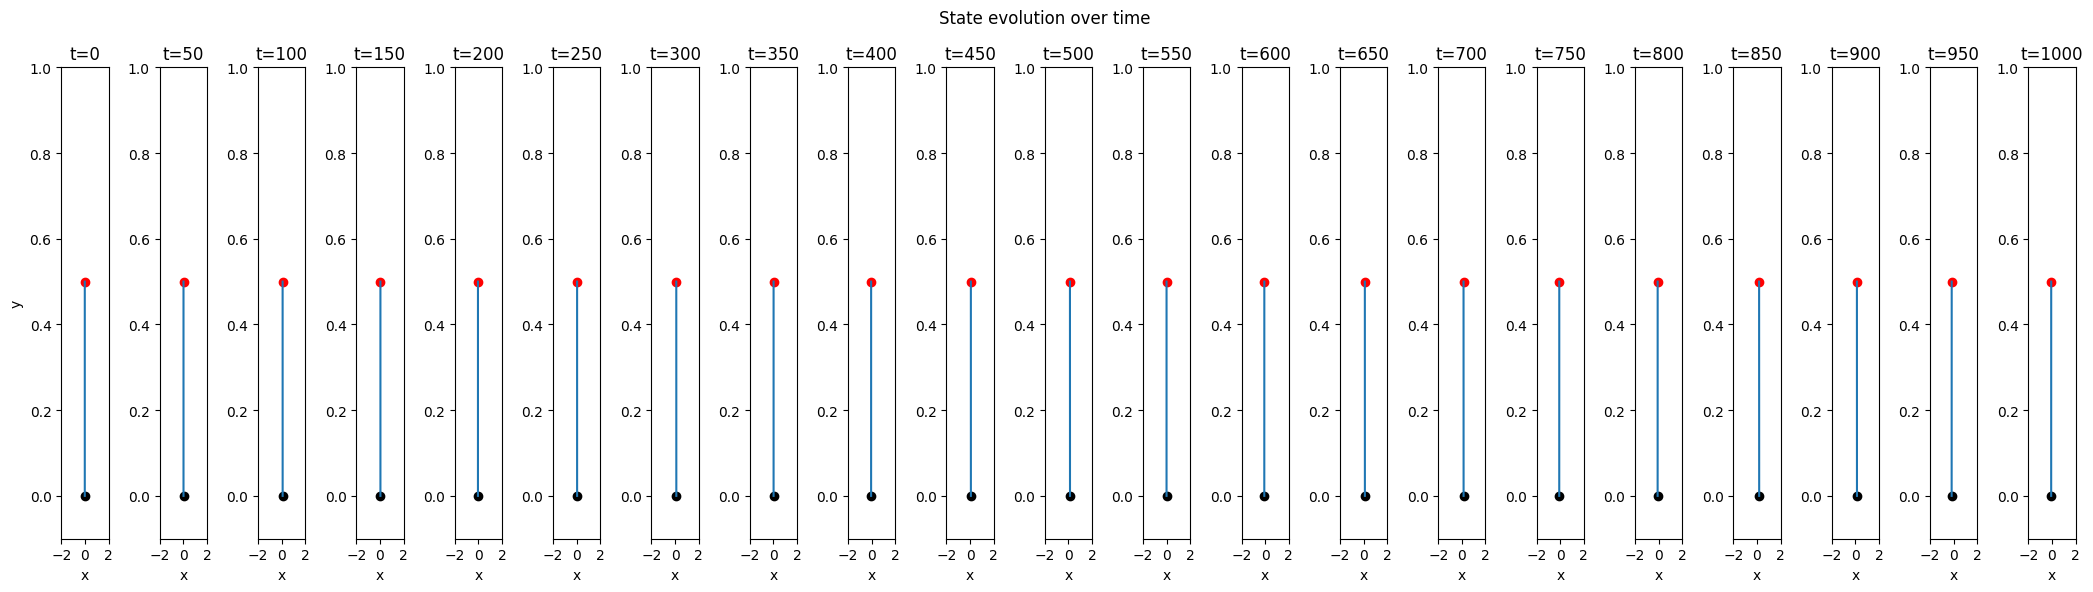

Total reward: 1000.0


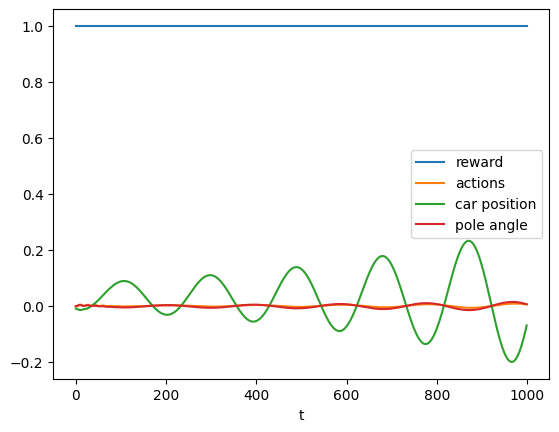

In [ ]:
# Key 10 (fitness = 1000)
key = jax.random.PRNGKey(10)
obs, env_state = env.reset(key)
compute_and_visualize(obs, env_state, policy, T)

### Multiple evaluation

In [ ]:
mujoco_env = MujocoGymnaxWrapper('CartpoleBalance')
policy = lambda obs: jnp.array([obs[0] + 4*obs[2] + obs[3] + 2*obs[4]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([obs[0] + 6.03*obs[2] + obs[3] + 1.51*obs[4]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

Module mujoco.mjx.third_party.mujoco_warp._src.solver b116efb load on device 'cuda:0' took 1972.13 ms  (compiled)
Module solve_init_jaref__locals__kernel_1024e45f 1024e45 load on device 'cuda:0' took 126.82 ms  (compiled)
Module mul_m_dense__locals___mul_m_dense_9e18c742 9e18c74 load on device 'cuda:0' took 204.27 ms  (compiled)
Module update_constraint_efc__locals__kernel_81015163 8101516 load on device 'cuda:0' took 251.53 ms  (compiled)
Module update_constraint_gauss_cost__locals__kernel_426b0947 426b094 load on device 'cuda:0' took 129.34 ms  (compiled)
Module update_gradient_JTDAJ_dense_tiled__locals__kernel_db6adfeb 2cf3ef2 load on device 'cuda:0' took 861.40 ms  (compiled)
Module update_gradient_cholesky__locals__kernel_2ebbd9c5 764264a load on device 'cuda:0' took 4417.69 ms  (compiled)
Module linesearch_iterative__locals__kernel_52ef4169 9b3d95e load on device 'cuda:0' took 1494.87 ms  (compiled)
Module update_constraint_efc__locals__kernel_25737258 2573725 load on device 'cud

In [ ]:
mujoco_env = MujocoGymnaxWrapper('CartpoleBalance')
policy = lambda obs: jnp.array([obs[0] - 0.159*obs[1]*obs[4] + 3*obs[2] + obs[4] + jnp.sin(2*obs[2] + obs[4] + jnp.sin(obs[2] + obs[3] + jnp.sin(obs[2])))])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([obs[0] + 6*obs[2] + obs[3] + 1.66*obs[4]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[999.678 999.893 999.882 999.429 999.821 999.695 999.803 999.589 999.87  999.539]
[999.686 999.897 999.883 999.44  999.824 999.704 999.807 999.599 999.871 999.549]


In [ ]:
mujoco_env = MujocoGymnaxWrapper('CartpoleBalance')
policy = lambda obs: jnp.array([obs[0] + 4*obs[2] + obs[3] + 2*obs[4]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([obs[0] + 6.03*obs[2] + obs[3] + 1.51*obs[4]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

Module mujoco.mjx.warp.ffi 98d2031 load on device 'cuda:0' took 558.99 ms  (compiled)
Module mujoco.mjx.third_party.mujoco_warp._src.smooth 95a0b8b load on device 'cuda:0' took 7275.10 ms  (compiled)
Module mujoco.mjx.third_party.mujoco_warp._src.constraint 981fdaf load on device 'cuda:0' took 3550.88 ms  (compiled)
Module mujoco.mjx.third_party.mujoco_warp._src.forward f60f76d load on device 'cuda:0' took 2977.55 ms  (compiled)
Module mujoco.mjx.third_party.mujoco_warp._src.passive 1a5e55c load on device 'cuda:0' took 1774.54 ms  (compiled)
Module mujoco.mjx.third_party.mujoco_warp._src.forward 8ebfcb1 load on device 'cuda:0' took 2101.41 ms  (compiled)
Module mujoco.mjx.third_party.mujoco_warp._src.support dd3f924 load on device 'cuda:0' took 354.93 ms  (compiled)
Module _tile_cholesky_factorize_solve__locals__cholesky_factorize_solve_2f3988cb 280e0ec load on device 'cuda:0' took 4912.57 ms  (compiled)
Module mujoco.mjx.third_party.mujoco_warp._src.solver b116efb load on device 'cuda

In [ ]:
mujoco_env = MujocoGymnaxWrapper('CartpoleBalance')
policy = lambda obs: jnp.array([obs[0] - 0.159*obs[1]*obs[4] + 3*obs[2] + obs[4] + jnp.sin(2*obs[2] + obs[4] + jnp.sin(obs[2] + obs[3] + jnp.sin(obs[2])))])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([obs[0] + 6*obs[2] + obs[3] + 1.66*obs[4]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[999.678 999.893 999.882 999.429 999.821 999.695 999.803 999.589 999.87  999.539]
[999.686 999.897 999.883 999.44  999.824 999.704 999.807 999.599 999.871 999.549]


In [ ]:
mujoco_env = MujocoGymnaxWrapper('CartpoleBalance')
policy = lambda obs: jnp.array([obs[0] + 5.51*obs[2] + obs[3] + obs[4] + (obs[2]+obs[4])*(obs[0]*(obs[0]+obs[4])+0.646)])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([obs[0] + 5.51*obs[2] + obs[3] + obs[4]+ (0.646-1.52*obs[2])*(obs[2]+obs[4])])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[999.686 999.897 999.883 999.441 999.824 999.706 999.807 999.6   999.872 999.55 ]
[999.686 999.897 999.883 999.441 999.824 999.706 999.807 999.599 999.872 999.55 ]


In [ ]:
mujoco_env = MujocoGymnaxWrapper('CartpoleBalance')
policy = lambda obs: jnp.array([obs[0] + 4.4*obs[2] + obs[3] + 2*obs[4]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([obs[0] + 6.75*obs[2] + obs[3] + 2*obs[4]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[999.519 999.783 999.824 999.228 999.769 999.471 999.752 999.37  999.797 999.34 ]
[999.667 999.887 999.881 999.416 999.818 999.68  999.8   999.573 999.869 999.525]


## Reacher

Action space: $[-1, 1]^2$, where the first action is the torque applied at the first hinge (connecting the link to the point of fixture), and the second action the torque applied at the second hinge (connecting the two links)

Observation space: $ℝ^{11}$

0.   cos(joint0)
1.   cos(joint1)
2.   sin(joint0)
3.   sin(joint1)
4.   target_x
5.   target_y
6.   ang_vel joint 0
7.   ang_vel joint 1
8.   diff x-value
9.   diff y-value
10.  (diff z-value)

The reward consists of two parts:

  - *reward_dist*: distance between *fingertip* of the reacher and the target,  with a more negative value assigned when *fingertip* is further away.
  
  - *reward_ctrl*: A negative reward for penalising too large actions. Measured as the negative squared Euclidean norm of the action.


   The episode terminates when episode duration reaches a 1000 timesteps


### Visualize best solution

In [ ]:
env = MujocoGymnaxWrapper("ReacherEasy")
T = 1000
#env = EpisodeWrapper(envs.get_environment("reacher"), episode_length=T, action_repeat=1)

### Complexity 4, [y10-y7, y8]

In [ ]:
policy = lambda obs: jnp.tanh(jnp.array([obs[10]-obs[7], obs[8]])) #[y10-y7, y8]

Timestep 0 : x-coordinate tip: 0.1978592574596405 | y-coordinate tip: -0.02795960009098053 | Angular velocity joint 1: -1.5067639651533682e-05 | Angular velocity joint 2: 0.08846640586853027 | 
Timestep 50 : x-coordinate tip: 0.04262208566069603 | y-coordinate tip: -0.04259457066655159 | Angular velocity joint 1: -0.08862285315990448 | Angular velocity joint 2: 0.08662891387939453 | 
Timestep 100 : x-coordinate tip: -0.020069293677806854 | y-coordinate tip: -0.0267593115568161 | Angular velocity joint 1: -0.08444003015756607 | Angular velocity joint 2: -0.055956996977329254 | 
Timestep 150 : x-coordinate tip: -0.008616223931312561 | y-coordinate tip: -0.01580703631043434 | Angular velocity joint 1: 0.07782018184661865 | Angular velocity joint 2: -0.05819129943847656 | 
Timestep 200 : x-coordinate tip: 0.026616282761096954 | y-coordinate tip: -0.03504784032702446 | Angular velocity joint 1: -0.15493617951869965 | Angular velocity joint 2: 0.09234896302223206 | 
Timestep 250 : x-coordina

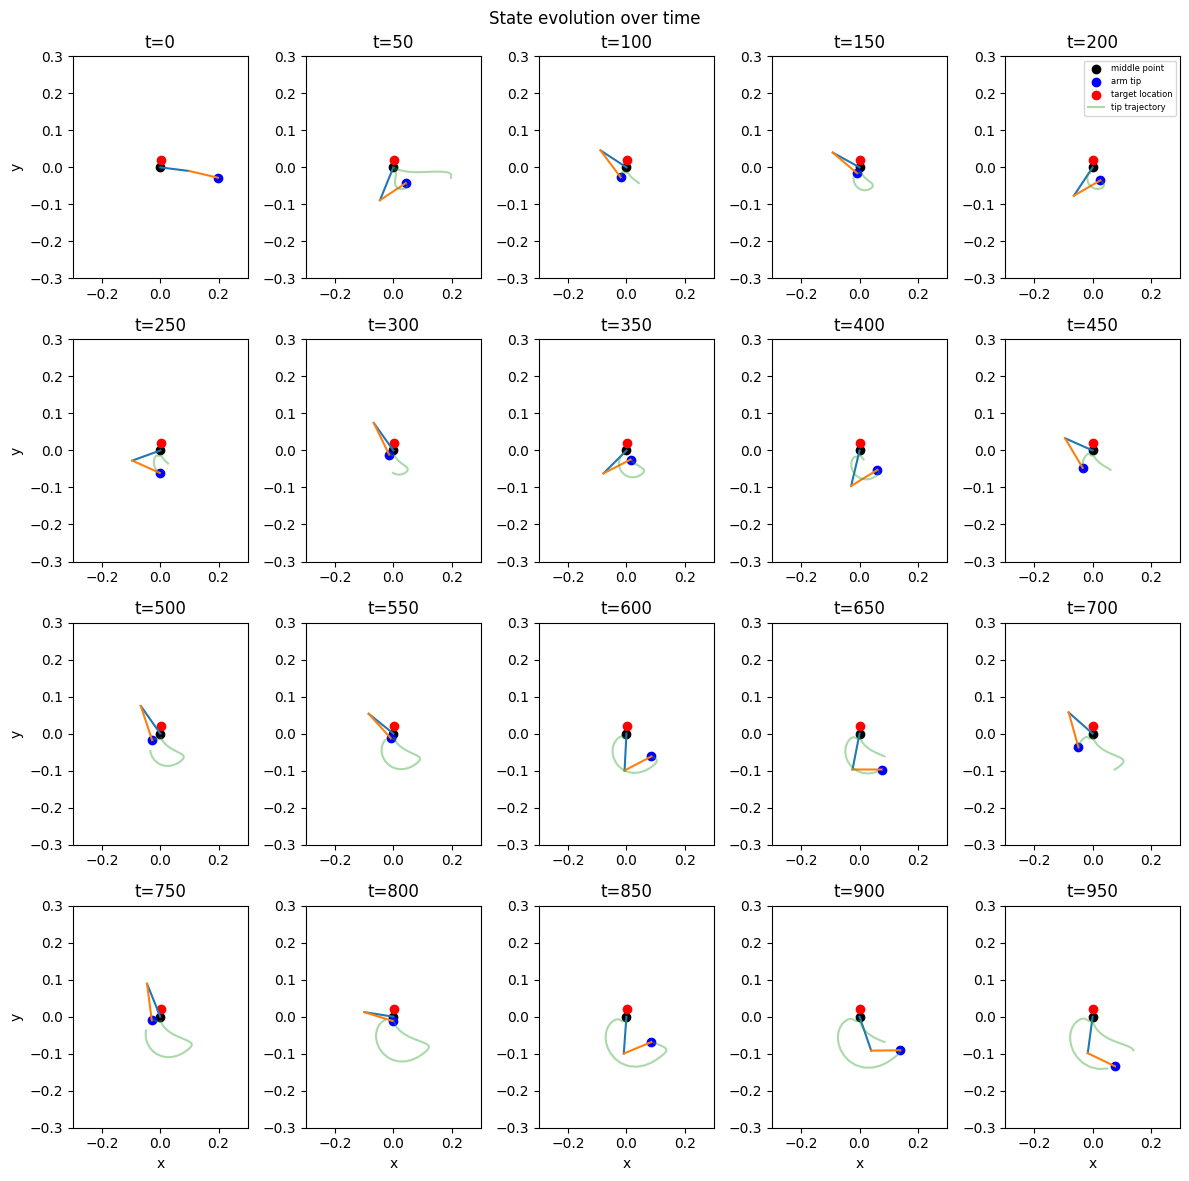

Total reward: -117.40674


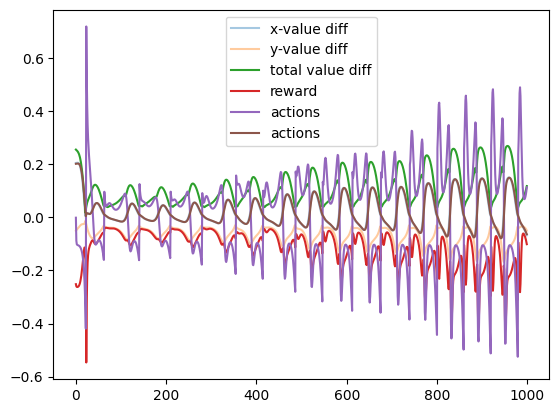

In [ ]:
# Key 0 (fitness = -117.41)
key = jax.random.PRNGKey(0)
obs, env_state = env.reset(key)
compute_and_visualize(obs, env_state, policy, T)

Timestep 0 : x-coordinate tip: 0.1999620944261551 | y-coordinate tip: -0.003653876483440399 | Angular velocity joint 1: 2.1947597872440383e-07 | Angular velocity joint 2: 0.09323481470346451 | 
Timestep 50 : x-coordinate tip: 0.006071537733078003 | y-coordinate tip: -0.01274559274315834 | Angular velocity joint 1: -0.035539787262678146 | Angular velocity joint 2: -0.017025716602802277 | 
Timestep 100 : x-coordinate tip: 0.004351608455181122 | y-coordinate tip: -0.01344306394457817 | Angular velocity joint 1: -0.00020217899873387069 | Angular velocity joint 2: -9.435066021978855e-05 | 
Timestep 150 : x-coordinate tip: 0.004336893558502197 | y-coordinate tip: -0.013447841629385948 | Angular velocity joint 1: -7.673772870475659e-07 | Angular velocity joint 2: -1.0589736803012784e-06 | 
Timestep 200 : x-coordinate tip: 0.004337139427661896 | y-coordinate tip: -0.01344776526093483 | Angular velocity joint 1: 1.1594735269682133e-06 | Angular velocity joint 2: -1.6526951185369398e-07 | 
Times

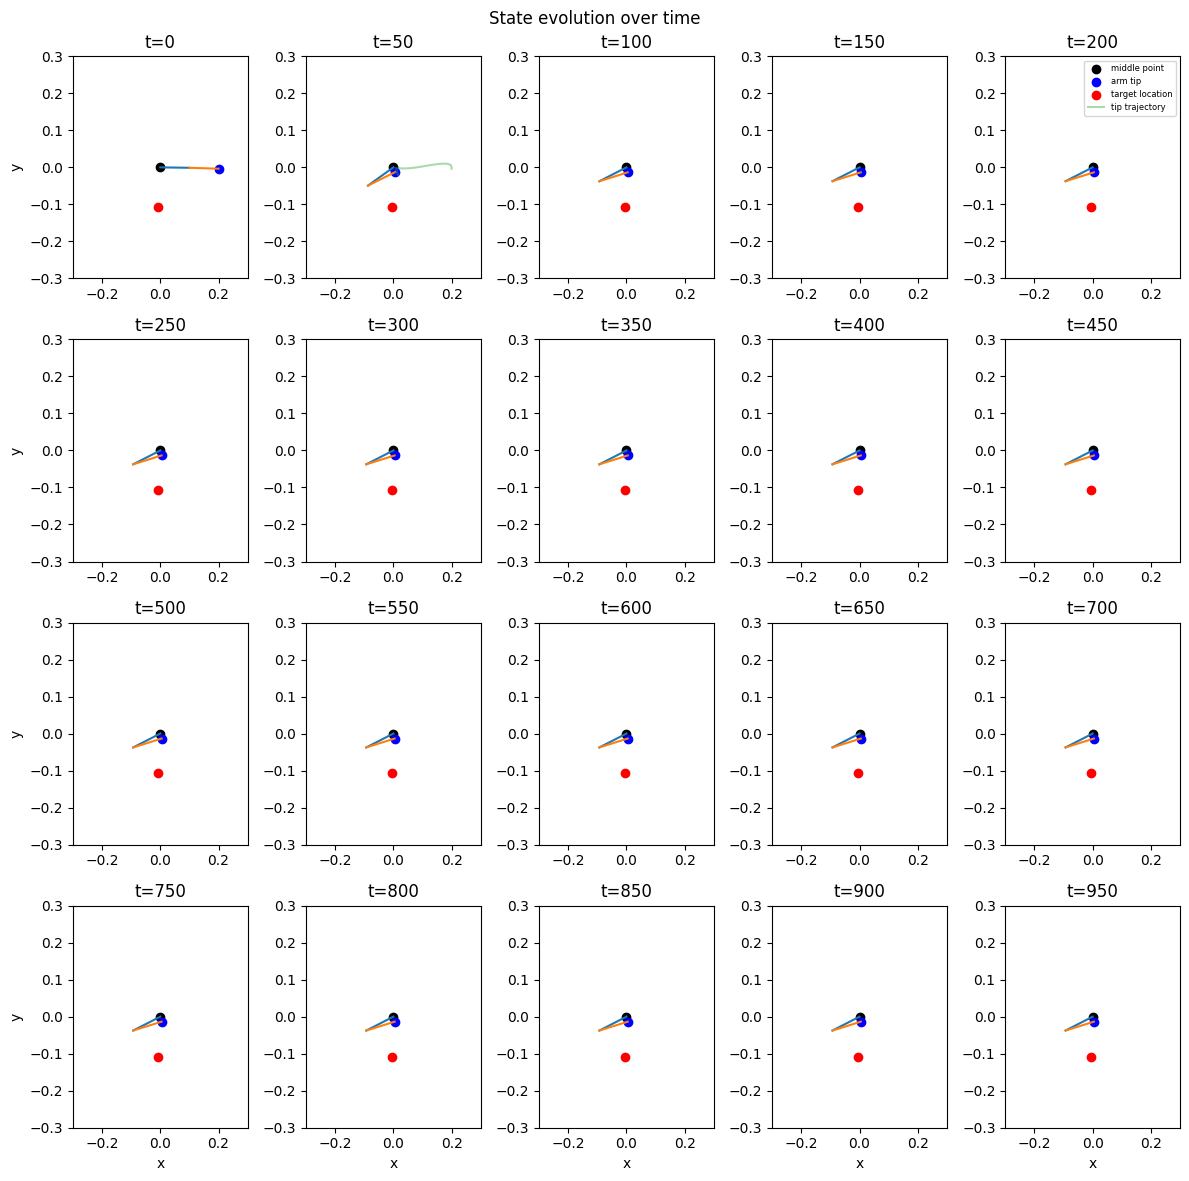

Total reward: -103.9883


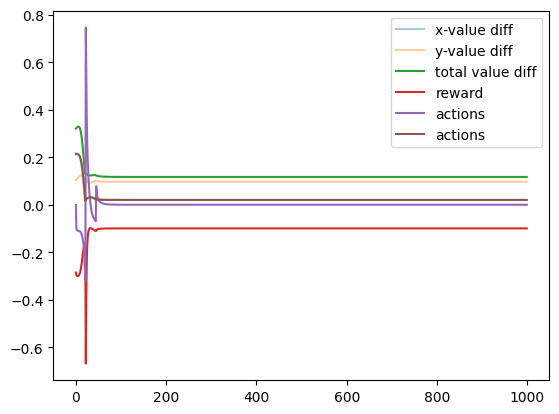

In [ ]:
# Key 26 (fitness = -103.99)
key = jax.random.PRNGKey(26)
obs, env_state = env.reset(key)
compute_and_visualize(obs, env_state, policy, T)

Timestep 0 : x-coordinate tip: 0.19919002056121826 | y-coordinate tip: -0.01797184906899929 | Angular velocity joint 1: 1.1495327271404676e-05 | Angular velocity joint 2: 0.07784523069858551 | 
Timestep 50 : x-coordinate tip: 0.06594780832529068 | y-coordinate tip: -0.03038223832845688 | Angular velocity joint 1: -0.04294491186738014 | Angular velocity joint 2: 0.047510623931884766 | 
Timestep 100 : x-coordinate tip: 0.035964708775281906 | y-coordinate tip: -0.030038584023714066 | Angular velocity joint 1: 0.06155731901526451 | Angular velocity joint 2: 0.0262864138931036 | 
Timestep 150 : x-coordinate tip: 0.007797963917255402 | y-coordinate tip: -0.019620545208454132 | Angular velocity joint 1: 0.02284296229481697 | Angular velocity joint 2: -0.040569085627794266 | 
Timestep 200 : x-coordinate tip: 0.01632801443338394 | y-coordinate tip: -0.01889236643910408 | Angular velocity joint 1: -0.08790755271911621 | Angular velocity joint 2: 0.00937497615814209 | 
Timestep 250 : x-coordinate

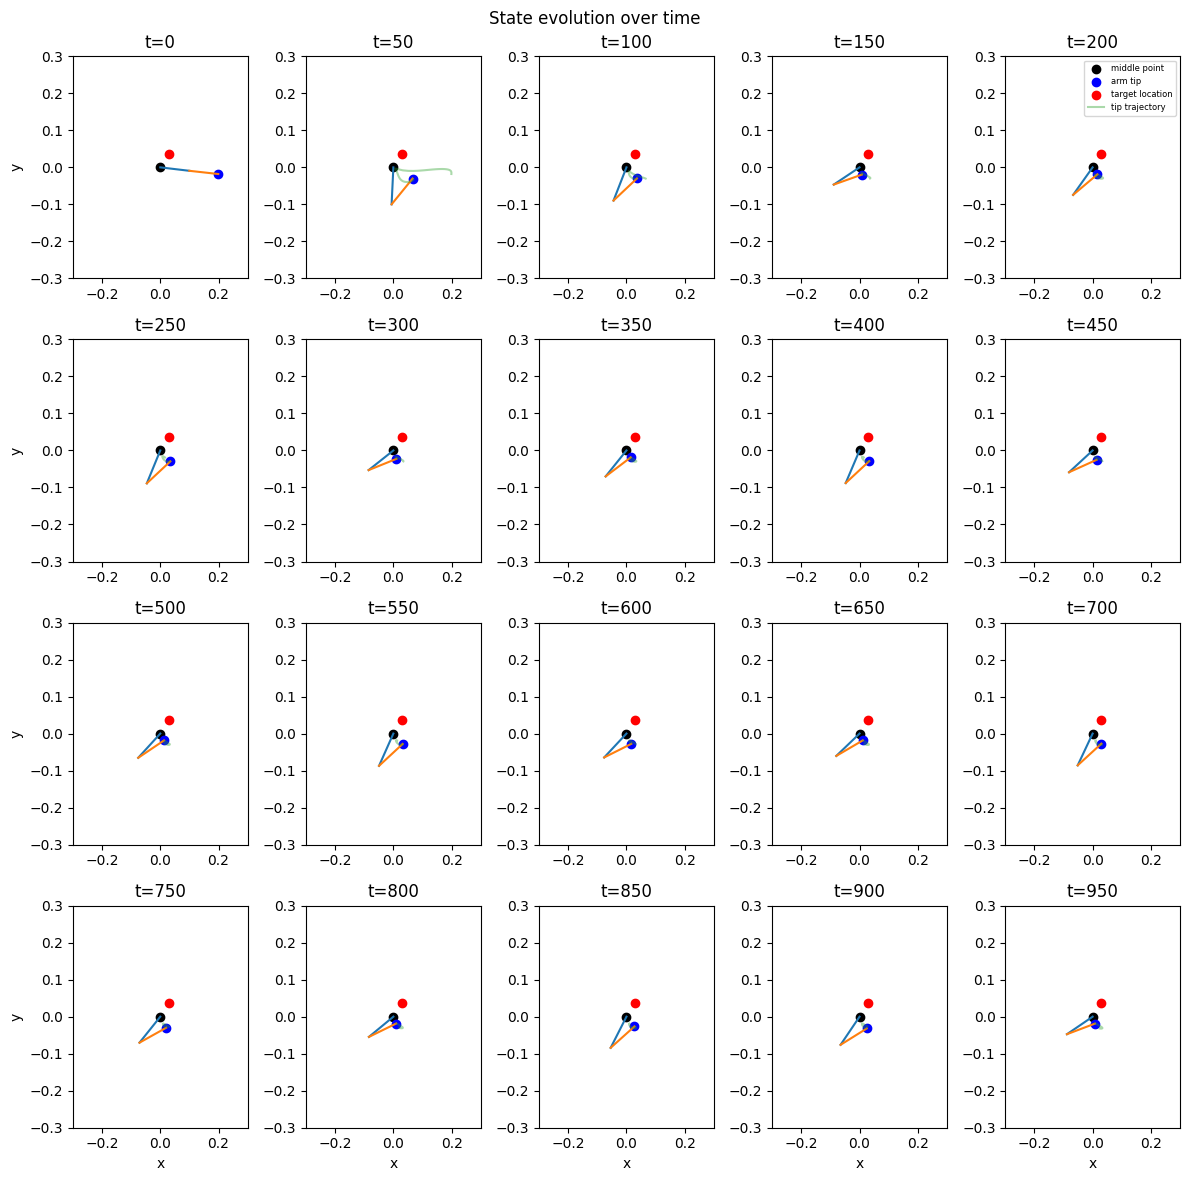

Total reward: -61.563126


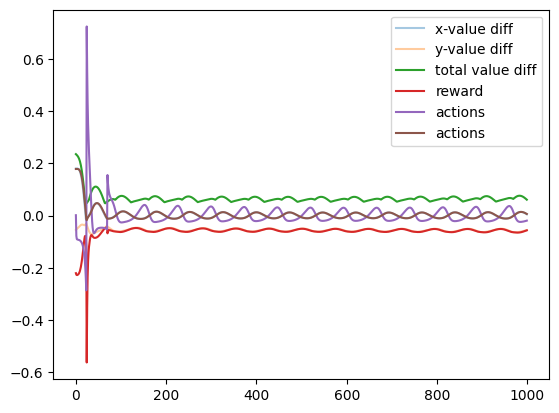

In [ ]:
# Key 10 (fitness = -61.56)
key = jax.random.PRNGKey(10)
obs, env_state = env.reset(key)
compute_and_visualize(obs, env_state, policy, T)

### Multiple evaluation

In [ ]:
mujoco_env = MujocoGymnaxWrapper('ReacherEasy')
policy = lambda obs: jnp.array([obs[0]*obs[2] + obs[2] - obs[3], 2*obs[0]*obs[1]*obs[3] + 2*obs[0]*obs[2] + obs[0]*obs[3] + 2*obs[2] - obs[3]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([4*obs[0]*jnp.sin(obs[3]) + 2*obs[2] + 5*obs[3] + jnp.sin(obs[2]), obs[5]*(obs[0]*jnp.sin(obs[3]) + obs[2] + 2*obs[3] + jnp.sin(obs[2])) + jnp.sin(obs[2])])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[  0. 969. 956. 965.   0. 950. 910.   0. 953. 945.]
[988. 950. 908. 932. 921. 564.  39. 835. 921. 948.]


In [ ]:
mujoco_env = MujocoGymnaxWrapper('ReacherEasy')
policy = lambda obs: jnp.array([3*obs[0]*(2*obs[2]*jnp.sin(obs[1]) + obs[3]) + 2*obs[2]**2 + 2*obs[2]*jnp.sin(obs[1]) + 6*obs[2] + 7*obs[3], 3*obs[0]*(2*obs[2]*jnp.sin(obs[1]) + obs[3]) + obs[0]*(obs[0]*(2*obs[2]*jnp.sin(obs[1]) + obs[3]) + obs[2]**2 + 4*obs[2] + 3*obs[3]) + 2*obs[2]*jnp.sin(obs[1]) + 7*obs[2] + 2*obs[3]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([-2.69*obs[0]*obs[2] + 2*obs[0]*obs[3]**2 - obs[0]*(2*obs[0]*obs[3]**2 + 2*obs[2]) + 2*obs[2] + 4*obs[3], 2*obs[0]*obs[3]**2 + 2*obs[0]*obs[3] + obs[0]*(-1.35*obs[0]*obs[2] - obs[0]*(2*obs[0]*obs[3]**2 + 2*obs[2]) + 2*obs[2] + 2*obs[3]) + 8*obs[2]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[989. 921. 965. 955. 931.  50. 928. 947. 918. 884.]
[977. 929. 966.   0. 935.  63. 202. 971. 265. 913.]


In [ ]:
mujoco_env = MujocoGymnaxWrapper('ReacherEasy')
policy = lambda obs: jnp.array([obs[1]*obs[3] + 3*obs[3], -1.15*obs[0]*(obs[1]*obs[3] + obs[3]) + obs[1]*obs[3] - 1.15*obs[2] - 2.29*obs[3]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([3*obs[2] + 4*obs[3], -2.46*obs[0]*(obs[2] + obs[3]) + obs[1]*(-2.46*obs[0]*(obs[2] + obs[3]) - 2.46*obs[2]) - 2.46*obs[2]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[ 77. 817. 838.  50. 732.   0. 963. 566.  90. 748.]
[  0.   0. 866. 664. 763. 336.  94. 945.  70.   0.]


In [ ]:
mujoco_env = MujocoGymnaxWrapper('ReacherEasy')
policy = lambda obs: jnp.array([obs[2]*obs[5]*(obs[0]*obs[3] + obs[2]) + obs[2]*(obs[0]*obs[3] + obs[2]) + obs[2] + obs[3]*obs[4]*(obs[2] + obs[3]) + obs[3] + jnp.sin(obs[0]*obs[1]*(obs[2]*obs[5]*(obs[0]*obs[3] + obs[2]) + obs[2] + obs[3]*obs[4]*(obs[2] + obs[3])) + obs[3]), 2*obs[0]*obs[3] + obs[2]*obs[5]*(obs[0]*obs[3] + obs[2]) + 2*obs[2] + 2*obs[3]*obs[4]*(obs[2] + obs[3]) + obs[3]*(obs[2] + obs[3])])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([obs[0]*obs[1]*(obs[1]*obs[3]*(-1.97*obs[0]*obs[3] - 1.97*obs[2] - 1.97*obs[3]) + 3*obs[2]) + obs[1]*(-1.97*obs[0]*obs[3] - 1.97*obs[2] - 1.97*obs[3]) + obs[3] + jnp.sin(obs[0]*obs[1]*(obs[1]*obs[3]*(-1.97*obs[0]*obs[3] - 1.97*obs[2] - 1.97*obs[3]) + 3*obs[2]) + obs[3]) + jnp.sin(jnp.sin(obs[0]*obs[1]*(obs[1]*obs[3]*(-1.97*obs[0]*obs[3] - 1.97*obs[2] - 1.97*obs[3]) + 3*obs[2]) + obs[3])) + jnp.sin(jnp.sin(jnp.sin(obs[0]*obs[1]*(obs[1]*obs[3]*(-1.97*obs[0]*obs[3] - 1.97*obs[2] - 1.97*obs[3]) + 3*obs[2]) + obs[3]))), 1.03*obs[0]*obs[3] + 2*obs[1]*obs[3]*(-1.97*obs[0]*obs[3] - 1.97*obs[2] - 1.97*obs[3]) + 6.03*obs[2] + 0.0306*obs[3]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[985. 893. 955. 930. 885. 237. 874.   0. 878. 863.]
[984.   0. 965. 951. 922.  10. 683.   9. 332. 976.]


In [ ]:
mujoco_env = MujocoGymnaxWrapper('ReacherEasy')
policy = lambda obs: jnp.array([2*obs[3]**2 + 5*obs[3], -2.26*obs[0]*obs[3] - 4.53*obs[2] - 2.26*obs[3]*obs[5] - 2.26*obs[3]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([obs[3]*obs[5] + 6*obs[3], -4.53*obs[0]*obs[3] - 4.53*obs[2] - 2.26*obs[3] - 0.245])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[ 71. 947. 720.  53. 642.   0. 181. 928. 810. 873.]
[525. 936. 919. 257. 821.   7. 911. 496. 916. 952.]


In [ ]:
mujoco_env = MujocoGymnaxWrapper('ReacherEasy')
policy = lambda obs: jnp.array([2*obs[3]**2 + 5*obs[3], -2.26*obs[0]*obs[3] - 4.53*obs[2] - 2.26*obs[3]*obs[5] - 2.26*obs[3]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([obs[3]*obs[5] + 6*obs[3], -4.53*obs[0]*obs[3] - 4.53*obs[2] - 2.26*obs[3] - 0.245])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[ 71. 947. 720.  53. 642.   0. 181. 928. 810. 873.]
[525. 936. 919. 257. 821.   7. 911. 496. 916. 952.]


## Swimmer

Action space: $[-1, 1]^2$, where the first action is the torque applied on the first rotor, and the second action the torque applied on the second rotor.

Observation space: $ℝ^{8}$

0.   angle_front_tip
1.   angle_second_rotor
2.   angle_third_rotor
3.   velocity_tip_x-axis
4.   velocity_tip_y-axis
5.   angular_velocity_front_tip
6.   angular_velocity_second_rotor
7.   angular_velocity_third_rotor

The reward consists of two parts:

  - *reward_fwd*: A reward of moving forward which is measured as (x-coordinate before action - x-coordinate after action) / dt.
  
  - *reward_ctrl*: A negative reward for penalising too large actions. Measured as *-coefficient x sum(action<sup>2</sup>)*


   The episode terminates when episode duration reaches a 1000 timesteps

### Visualize best solution

In [ ]:
from mujoco_playground._src.dm_control_suite.swimmer import Swim

Swimmer_env = Swim(n_links=3)
mujoco_env = MujocoGymnaxWrapper(env_instance = Swimmer_env)
T = 1000

### Complexity 8, [y6-y2+y5+y4, y4]

In [ ]:
policy = lambda obs: jnp.tanh(jnp.array([obs[6]-obs[2]+obs[5]+obs[4], obs[4]])) #[y6-y2+y5+y4, y4]

Timestep 0 : x-coordinate tip: -0.5952616930007935 | y-coordinate tip: -0.0695459172129631 | 
Timestep 50 : x-coordinate tip: -0.15299326181411743 | y-coordinate tip: 0.01723402738571167 | 
Timestep 100 : x-coordinate tip: 0.4906699061393738 | y-coordinate tip: -0.31312239170074463 | 
Timestep 150 : x-coordinate tip: 1.2531626224517822 | y-coordinate tip: -0.23849841952323914 | 
Timestep 200 : x-coordinate tip: 1.9460896253585815 | y-coordinate tip: 0.12197916954755783 | 
Timestep 250 : x-coordinate tip: 2.680694103240967 | y-coordinate tip: 0.048597514629364014 | 
Timestep 300 : x-coordinate tip: 3.3786532878875732 | y-coordinate tip: -0.33065104484558105 | 
Timestep 350 : x-coordinate tip: 4.1260809898376465 | y-coordinate tip: -0.3168222904205322 | 
Timestep 400 : x-coordinate tip: 4.844978332519531 | y-coordinate tip: 0.04369821026921272 | 
Timestep 450 : x-coordinate tip: 5.571459770202637 | y-coordinate tip: 0.02305203676223755 | 
Timestep 500 : x-coordinate tip: 6.28838157653808

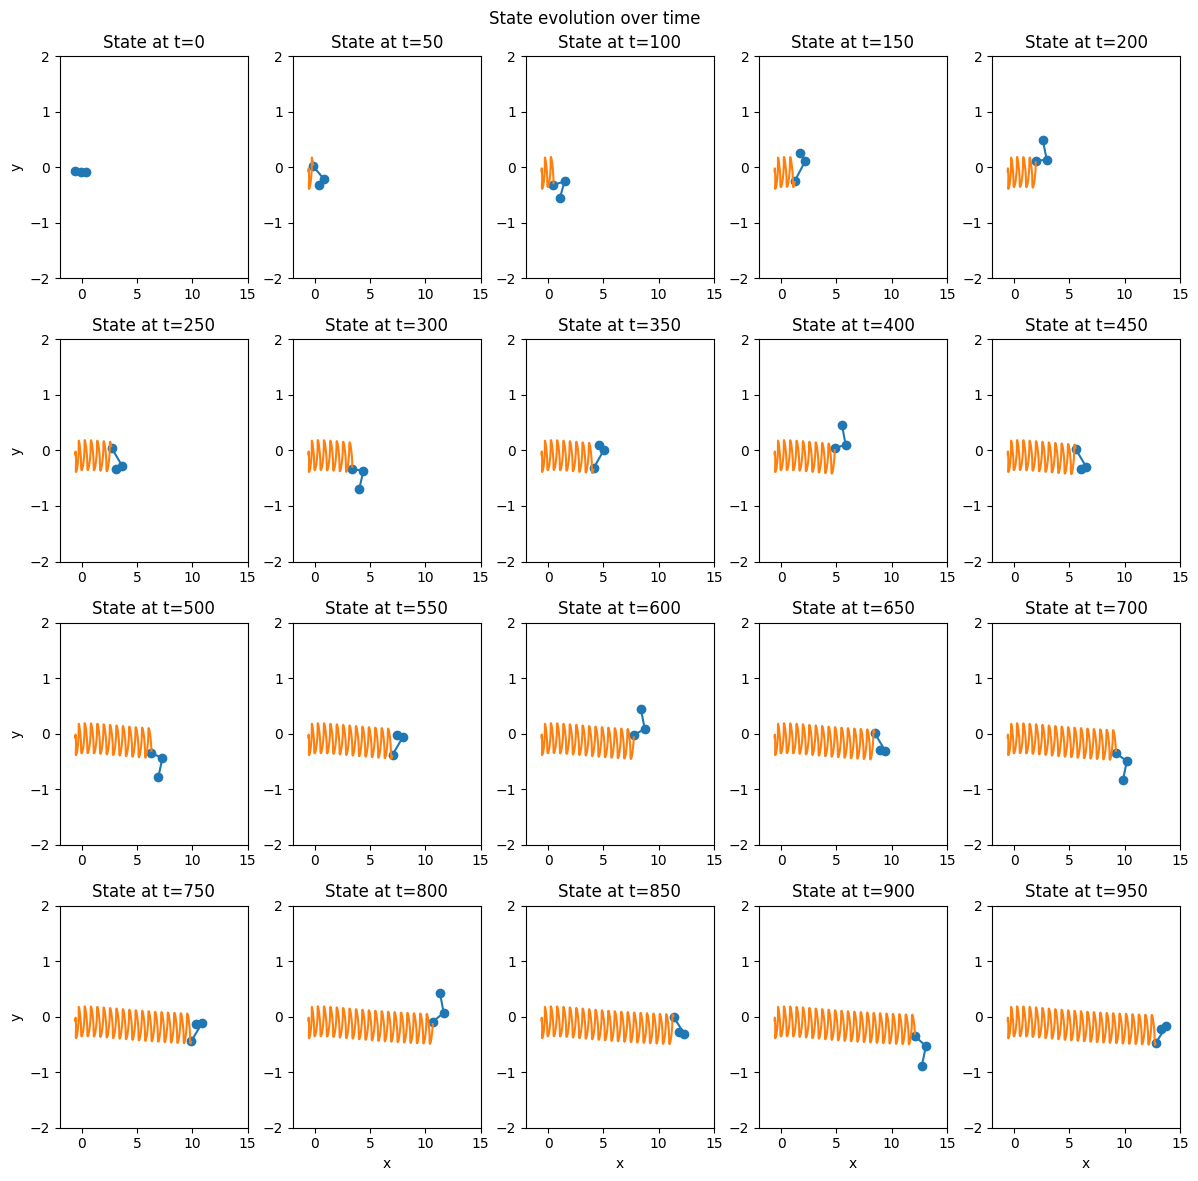

Total reward: 356.40808


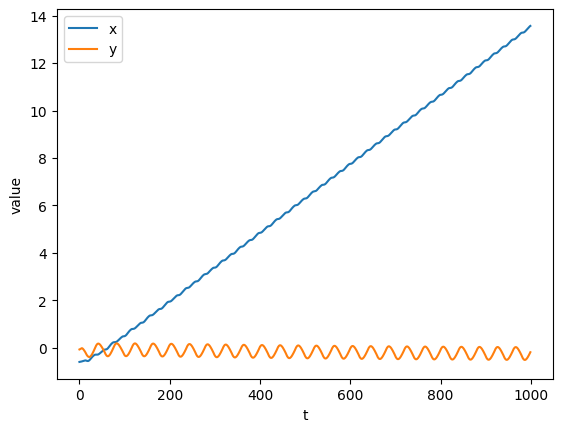

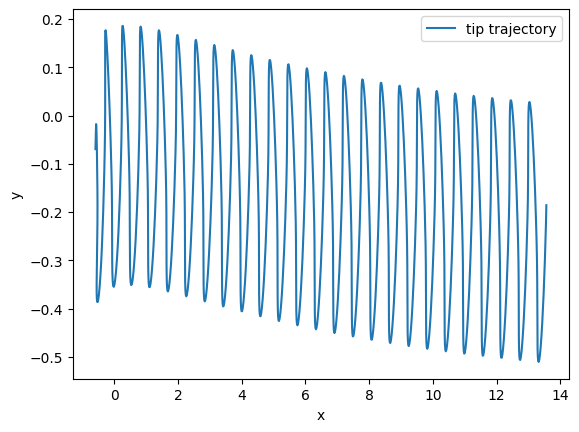

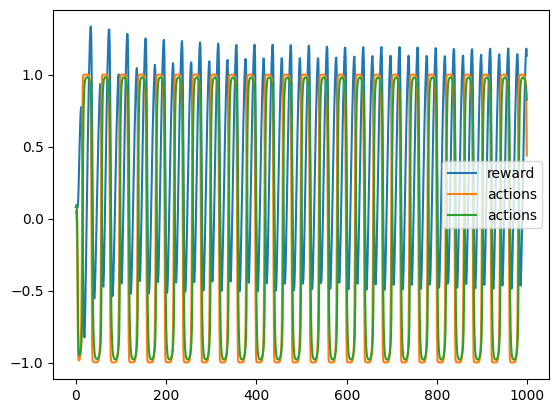

In [ ]:
# Key 0 (fitness = 356.41)
key = jax.random.PRNGKey(0)
obs, env_state = env.reset(key)
compute_and_visualize(obs, env_state, policy, T)

Timestep 0 : x-coordinate tip: -0.507975697517395 | y-coordinate tip: -0.056851185858249664 | 
Timestep 50 : x-coordinate tip: -0.07248026132583618 | y-coordinate tip: -0.05076013505458832 | 
Timestep 100 : x-coordinate tip: 0.5625081062316895 | y-coordinate tip: -0.31250494718551636 | 
Timestep 150 : x-coordinate tip: 1.3411948680877686 | y-coordinate tip: -0.10777382552623749 | 
Timestep 200 : x-coordinate tip: 2.000746726989746 | y-coordinate tip: 0.24299174547195435 | 
Timestep 250 : x-coordinate tip: 2.7793731689453125 | y-coordinate tip: 0.08598187565803528 | 
Timestep 300 : x-coordinate tip: 3.455386161804199 | y-coordinate tip: -0.25944969058036804 | 
Timestep 350 : x-coordinate tip: 4.231220245361328 | y-coordinate tip: -0.11097721755504608 | 
Timestep 400 : x-coordinate tip: 4.908596038818359 | y-coordinate tip: 0.24623936414718628 | 
Timestep 450 : x-coordinate tip: 5.68133544921875 | y-coordinate tip: 0.11961230635643005 | 
Timestep 500 : x-coordinate tip: 6.364796638488769

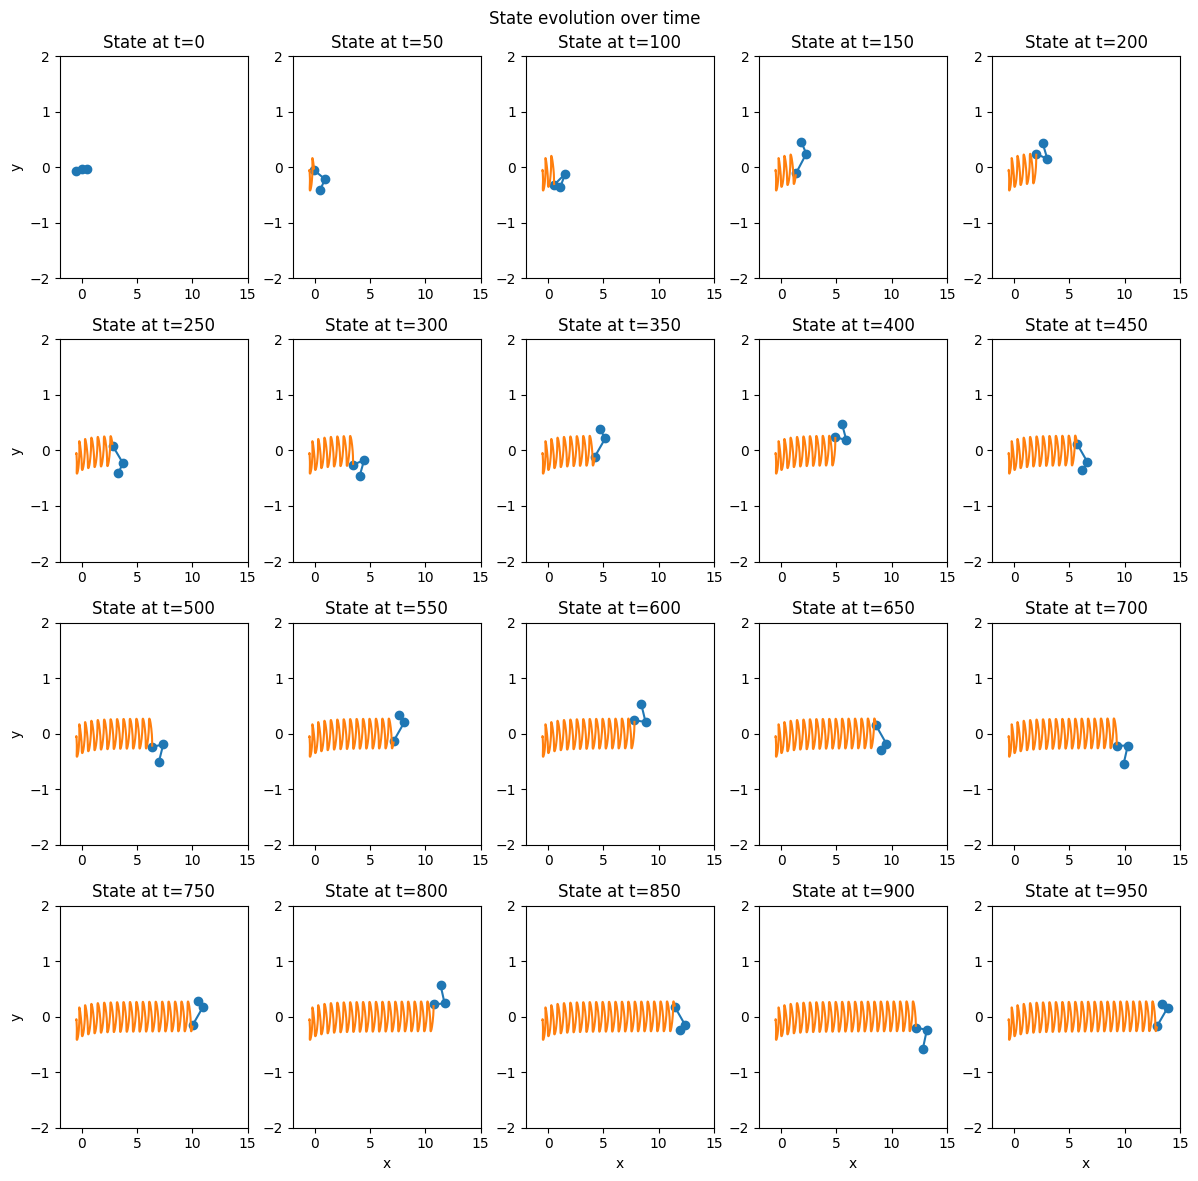

Total reward: 357.20612


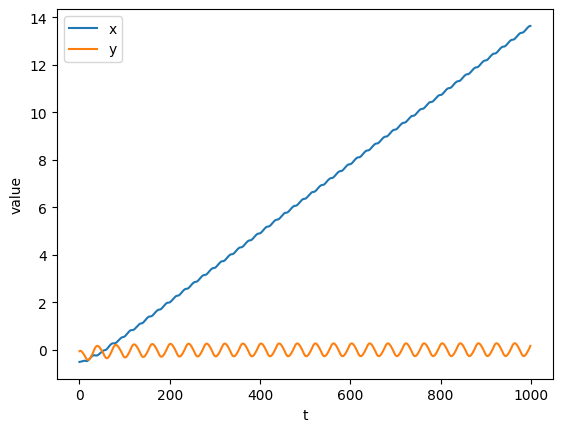

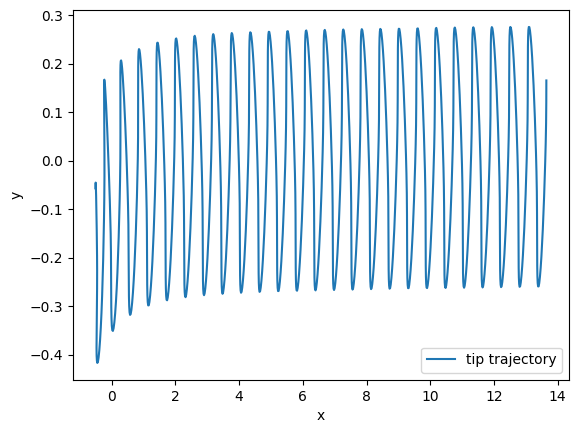

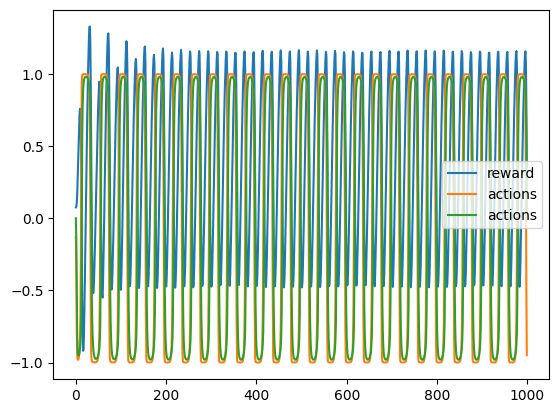

In [ ]:
# Key 26 (fitness = 357.21)
key = jax.random.PRNGKey(26)
obs, env_state = env.reset(key)
compute_and_visualize(obs, env_state, policy, T)

Timestep 0 : x-coordinate tip: -0.5920662879943848 | y-coordinate tip: -0.07921520620584488 | 
Timestep 50 : x-coordinate tip: -0.3544275164604187 | y-coordinate tip: -0.06375973671674728 | 
Timestep 100 : x-coordinate tip: 0.24941444396972656 | y-coordinate tip: -0.2971385717391968 | 
Timestep 150 : x-coordinate tip: 0.9981141090393066 | y-coordinate tip: -0.16425476968288422 | 
Timestep 200 : x-coordinate tip: 1.6759264469146729 | y-coordinate tip: 0.2353867143392563 | 
Timestep 250 : x-coordinate tip: 2.4312477111816406 | y-coordinate tip: 0.19622117280960083 | 
Timestep 300 : x-coordinate tip: 3.142556667327881 | y-coordinate tip: -0.16036513447761536 | 
Timestep 350 : x-coordinate tip: 3.881324529647827 | y-coordinate tip: -0.10498067736625671 | 
Timestep 400 : x-coordinate tip: 4.586308479309082 | y-coordinate tip: 0.2747514247894287 | 
Timestep 450 : x-coordinate tip: 5.328003883361816 | y-coordinate tip: 0.2701929807662964 | 
Timestep 500 : x-coordinate tip: 6.050943851470947 |

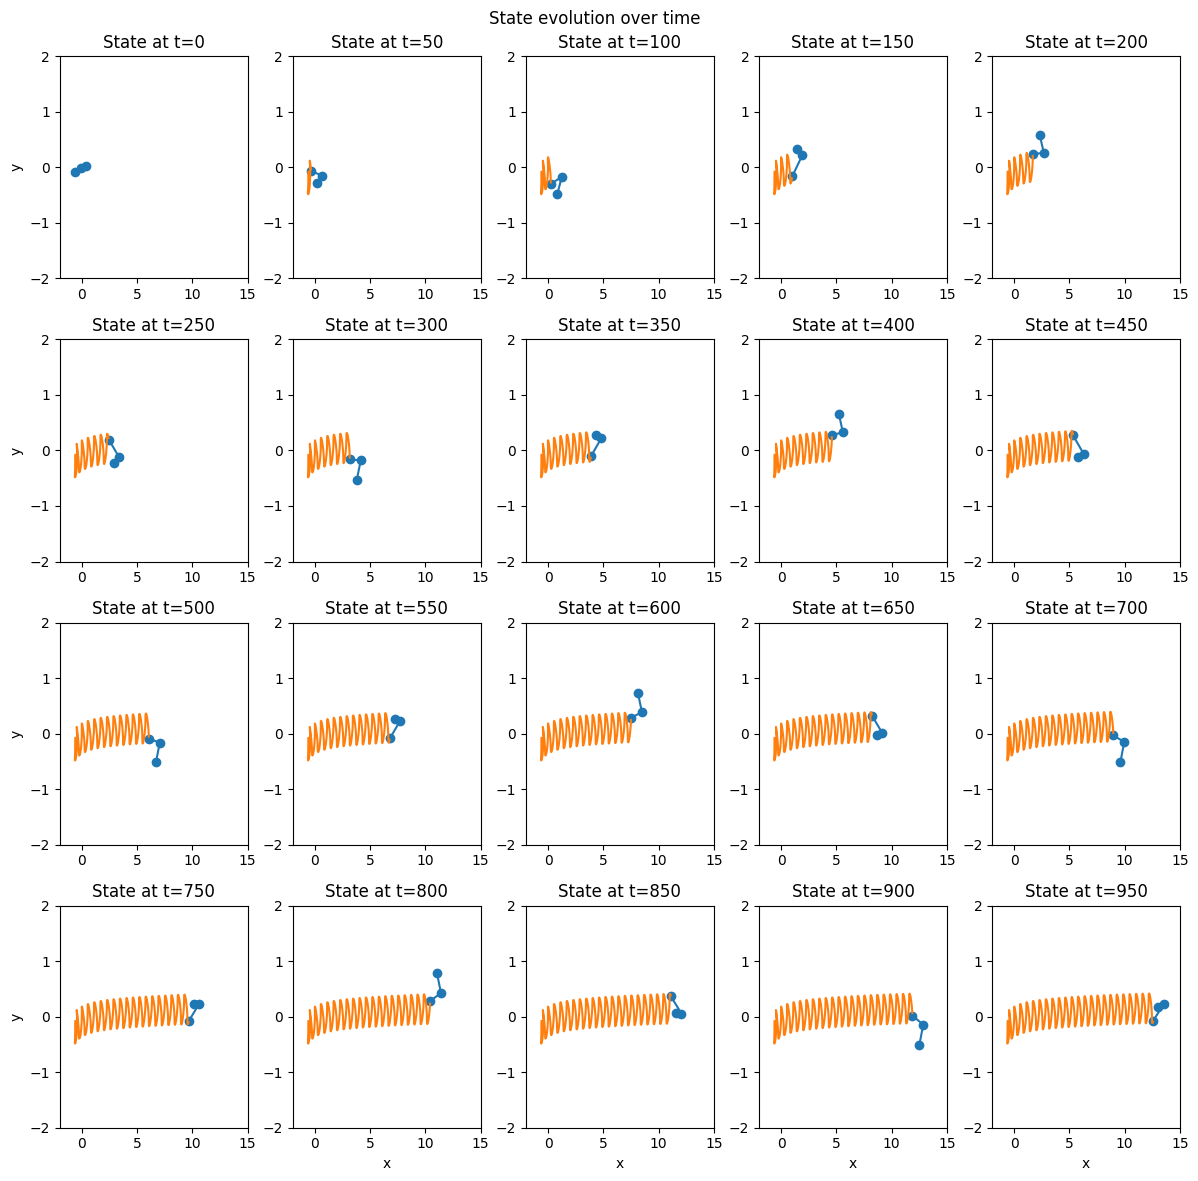

Total reward: 350.0511


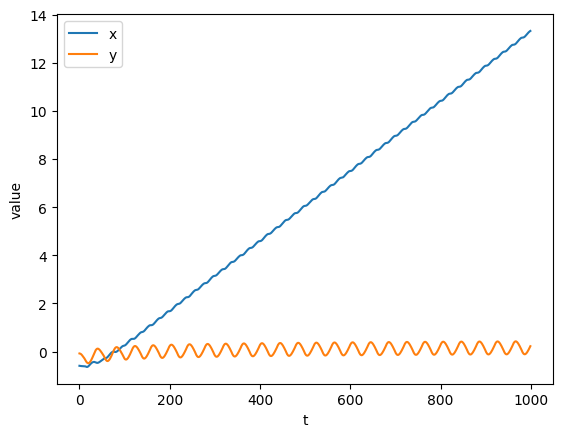

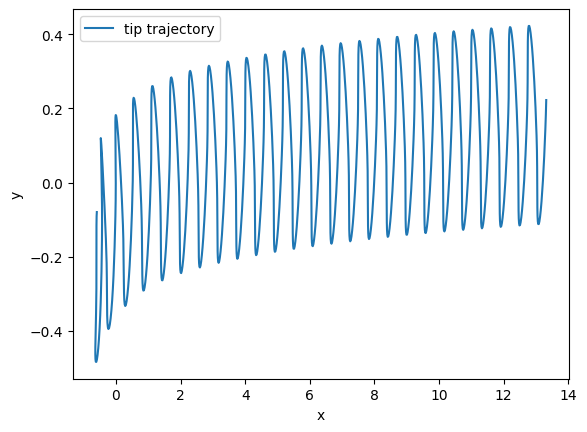

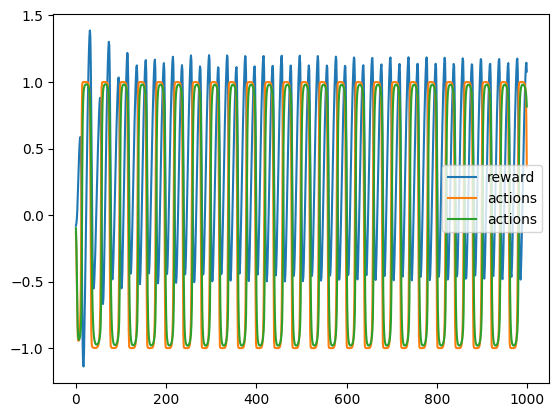

In [ ]:
# Key 10 (fitness = 350.05)
key = jax.random.PRNGKey(10)
obs, env_state = env.reset(key)
compute_and_visualize(obs, env_state, policy, T)

### Multiple evaluation

In [ ]:
from mujoco_playground._src.dm_control_suite.swimmer import Swim

Swimmer_env = Swim(n_links=3)
mujoco_env = MujocoGymnaxWrapper(env_instance = Swimmer_env)
policy = lambda obs: jnp.array([obs[11]*(obs[8] - obs[9]) + obs[2]*(obs[11]*(obs[8] - obs[9]) + obs[9]) + 2*obs[9], obs[11]*(obs[8] - obs[9]) + obs[2]*(obs[11]*(obs[8] - obs[9]) + obs[9]) - obs[2] + obs[3]*(obs[2]*(obs[11]*(obs[8] - obs[9]) + obs[9]) + obs[9]) + obs[8] - obs[9]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([-obs[2] + obs[3]*(obs[1] + obs[6]) + obs[5]*(-obs[2] + obs[3]*(obs[1] + obs[6])), obs[12] + obs[3]*(obs[12] + obs[5]*(-obs[2] + obs[3]*(obs[1] + obs[6]))) + obs[5]*(-obs[2] + obs[3]*(obs[1] + obs[6])) - obs[6]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

Module mujoco.mjx.third_party.mujoco_warp._src.sensor 7a62d05 load on device 'cuda:0' took 8544.77 ms  (compiled)
Module _tile_cholesky_factorize_solve__locals__cholesky_factorize_solve_f9126636 4908da2 load on device 'cuda:0' took 3914.04 ms  (compiled)
Module solve_init_jaref__locals__kernel_6e8468b3 6e8468b load on device 'cuda:0' took 151.84 ms  (compiled)
Module mul_m_dense__locals___mul_m_dense_f619f9d8 f619f9d load on device 'cuda:0' took 215.71 ms  (compiled)
Module update_constraint_gauss_cost__locals__kernel_84cf3b0a 84cf3b0 load on device 'cuda:0' took 147.67 ms  (compiled)
Module update_gradient_JTDAJ_dense_tiled__locals__kernel_dc766f91 aa19e9d load on device 'cuda:0' took 515.75 ms  (compiled)
Module update_gradient_cholesky__locals__kernel_8204ed89 a39c2f0 load on device 'cuda:0' took 4548.40 ms  (compiled)
Module linesearch_iterative__locals__kernel_94acdc55 9c914fd load on device 'cuda:0' took 1009.76 ms  (compiled)
[ 12.104  12.254 404.326  29.672  17.867  20.077   4.

In [ ]:
Swimmer_env = Swim(n_links=3)
mujoco_env = MujocoGymnaxWrapper(env_instance = Swimmer_env)
policy = lambda obs: jnp.array([obs[0]*obs[2]*obs[8]*(obs[0] + obs[2] + obs[9])*jnp.cos(0.322*obs[0]*obs[2]*obs[4]) + obs[0] + 2*obs[9], obs[0]*obs[2]*obs[8]*(obs[0] + obs[2] + obs[9])*jnp.cos(0.322*obs[0]*obs[2]*obs[4]) + obs[0] + 2*obs[2] + obs[3]*(obs[0]*obs[2]*obs[8]*(obs[0] + obs[2] + obs[9])*jnp.cos(0.322*obs[0]*obs[2]*obs[4]) + obs[2] + obs[9]) + obs[8]*(obs[0] + obs[2] + obs[9]) + 2*obs[9]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([obs[0] + obs[8]*(2*obs[2]**2 + 4*obs[3])*(obs[0] + obs[2] + obs[9]) + 2*obs[9], obs[0] + 3*obs[2] + obs[3]*(obs[2] + obs[3]*(obs[2] + obs[8]*(2*obs[2]**2 + 4*obs[3])*(obs[0] + obs[2] + obs[9]) + obs[9])) + 2*obs[3]*(obs[2] + obs[8]*(2*obs[2]**2 + 4*obs[3])*(obs[0] + obs[2] + obs[9]) + obs[9]) + obs[8]*(2*obs[2]**2 + 4*obs[3])*(obs[0] + obs[2] + obs[9]) + obs[8]*(obs[0] + obs[2] + obs[9]) + 2*obs[9]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[ 63.026  11.991 178.26   40.549  14.126  21.829   5.06    9.495  14.35  580.194]
[165.517  11.804 885.511  27.474  14.087  21.996  15.158   9.837  73.356 607.769]


In [ ]:
Swimmer_env = Swim(n_links=3)
mujoco_env = MujocoGymnaxWrapper(env_instance = Swimmer_env)
policy = lambda obs: jnp.array([-obs[0]*obs[3] + obs[1]*obs[3] + 2*obs[11]*obs[6] - 3*obs[2] + 3*obs[7], -obs[0]*obs[3] + obs[1]*obs[3] + 2*obs[11]*obs[6]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([-obs[0]*obs[3] + 2*obs[1]*obs[3] + 2*obs[10] + 2*obs[11]*obs[6] - 2*obs[2], -obs[0]*obs[3] + obs[1]*obs[3] + 2*obs[11]*obs[6]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

Module mujoco.mjx.third_party.mujoco_warp._src.sensor 7a62d05 load on device 'cuda:0' took 8698.45 ms  (compiled)
Module _tile_cholesky_factorize_solve__locals__cholesky_factorize_solve_f9126636 4908da2 load on device 'cuda:0' took 4093.95 ms  (compiled)
Module solve_init_jaref__locals__kernel_6e8468b3 6e8468b load on device 'cuda:0' took 152.90 ms  (compiled)
Module mul_m_dense__locals___mul_m_dense_f619f9d8 f619f9d load on device 'cuda:0' took 215.29 ms  (compiled)
Module update_constraint_gauss_cost__locals__kernel_84cf3b0a 84cf3b0 load on device 'cuda:0' took 148.12 ms  (compiled)
Module update_gradient_JTDAJ_dense_tiled__locals__kernel_dc766f91 aa19e9d load on device 'cuda:0' took 539.18 ms  (compiled)
Module update_gradient_cholesky__locals__kernel_8204ed89 a39c2f0 load on device 'cuda:0' took 4674.19 ms  (compiled)
Module linesearch_iterative__locals__kernel_94acdc55 9c914fd load on device 'cuda:0' took 1029.59 ms  (compiled)
[182.107 166.871 875.319 175.007 276.913 282.457  27.

In [ ]:
Swimmer_env = Swim(n_links=3)
mujoco_env = MujocoGymnaxWrapper(env_instance = Swimmer_env)
policy = lambda obs: jnp.array([obs[1]*(0.24*obs[2] - 0.24*obs[6] + 0.24*obs[9])*(obs[10] - 2*obs[2] - obs[6] + 2*obs[7]*obs[9] - obs[9]) + obs[10] - 3*obs[2] - obs[6] + 4*obs[7]*obs[9], obs[1]*(0.24*obs[2] - 0.24*obs[6] + 0.24*obs[9]) - 2.76*obs[2] + 0.76*obs[6] + 2*obs[7]*obs[9] - 1.76*obs[9]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([-0.48*obs[0]*obs[4]*(obs[10] + obs[9])*(obs[5] - obs[6] + 0.971) + obs[10] - 2*obs[2] - obs[6] + (0.971 - obs[6])*(-0.24*obs[0]*obs[4]*(obs[10] + obs[9])*(obs[5] - obs[6] + 0.971) + obs[10] - 2*obs[2] - obs[6] - obs[9]), -0.24*obs[0]*obs[4]*(obs[10] + obs[9])*(obs[5] - obs[6] + 0.971) - 0.24*obs[0]*obs[4]*(obs[10] + obs[9]) - 0.24*obs[0]*(obs[10] + obs[9]) - 2*obs[2] - obs[9]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[ 12.365  12.868 728.888  40.993  18.125  22.562   5.074  10.681   8.446  79.106]
[ 12.078  12.657 774.843  39.875  15.163  22.562   4.659  10.223   8.318 200.118]


In [ ]:
Swimmer_env = Swim(n_links=3)
mujoco_env = MujocoGymnaxWrapper(env_instance = Swimmer_env)
policy = lambda obs: jnp.array([-obs[11] - obs[2] + jnp.sin(jnp.sin(2*obs[9])), obs[1]*obs[3] + obs[2] + (2*obs[0] + obs[2])*(-obs[3] + obs[4])])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([-2*obs[2] + 2*obs[7] + obs[9] + jnp.sin(obs[2] - obs[6]), obs[0]*obs[2] + 2*obs[0] + 2*obs[1]*obs[3]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[ 26.32   27.653 806.277  27.3    13.956 122.688   8.635   9.857  17.045 467.509]
[151.363  11.571 890.806  48.916 285.77   25.361  20.033   9.853  46.375 639.611]


In [ ]:
Swimmer_env = Swim(n_links=3)
mujoco_env = MujocoGymnaxWrapper(env_instance = Swimmer_env)
policy = lambda obs: jnp.array([-obs[11] - obs[2] + jnp.sin(jnp.sin(2*obs[9])), obs[1]*obs[3] + obs[2] + (2*obs[0] + obs[2])*(-obs[3] + obs[4])])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([-2*obs[2] + 2*obs[7] + obs[9] + jnp.sin(obs[2] - obs[6]), obs[0]*obs[2] + 2*obs[0] + 2*obs[1]*obs[3]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[ 26.32   27.653 806.277  27.3    13.956 122.688   8.635   9.857  17.045 467.509]
[151.363  11.571 890.806  48.916 285.77   25.361  20.033   9.853  46.375 639.611]


## Hopper

Action space: $[-1, 1]^3$, where the first action is the torque applied on the thigh rotor, and the second action the torque applied on the leg rotor, and the thrid action the torque applied to the foot rotor.

Observation space: $ℝ^{11}$

0.   z-coordinate of the top
1.   angle_top
2.   angle_thigh_joint
3.   angle_leg_joint
4.   angle_foot_joint
5.   velocity_x-coordinate_top
6.   velocity_z-coordinate_top
7.   angular_velocity_angle_top
8.   angular_velocity_thigh_hinge
9.   angular_velocity_leg_hinge
10.  angular_velocity_foot_hinge

The reward consists of three parts:

  - *reward_healthy*: +1 reward for every timestep that the hopper is alive.

  - *reward_fwd*: A reward of moving forward which is measured as (x-coordinate before action - x-coordinate after action) / dt.
  
  - *reward_ctrl*: A negative reward for penalising too large actions. Measured as *-coefficient x sum(action<sup>2</sup>)*


   The episode terminates when episode duration reaches a 1000 timesteps, the height of the hopper becomes less than 0.7 metres, or the absolute value of the angle of the thigh joint is less than 0.2 radians

### Visualize

In [ ]:
env = MujocoGymnaxWrapper("HopperHop")
T = 1000

### Complexity 9, [0.1-y1-y2, 0.1-y1, y9]:

In [ ]:
policy = lambda obs: jnp.tanh(jnp.array([0.1-obs[1]-obs[2], 0.1-obs[1], obs[9]])) #[0.1-y1-y2, 0.1-y1, y9]

Timestep 0 : Height: 1.2448410987854004 | x-coordinate thigh: -0.007340631447732449 | Thigh angle (rad): 0.0016536053735762835 | 
Timestep 50 : Height: 1.201703429222107 | x-coordinate thigh: 0.005654461681842804 | Thigh angle (rad): 0.06940022110939026 | 
Timestep 100 : Height: 1.1871511936187744 | x-coordinate thigh: 0.038079991936683655 | Thigh angle (rad): 0.13577960431575775 | 
Timestep 150 : Height: 1.1816999912261963 | x-coordinate thigh: 0.05308057367801666 | Thigh angle (rad): 0.13629692792892456 | 
Timestep 200 : Height: 1.194880485534668 | x-coordinate thigh: 0.03449764847755432 | Thigh angle (rad): 0.0880519300699234 | 
Timestep 250 : Height: 1.182615041732788 | x-coordinate thigh: 0.05338284373283386 | Thigh angle (rad): 0.12604714930057526 | 
Timestep 300 : Height: 1.1709508895874023 | x-coordinate thigh: 0.07663683593273163 | Thigh angle (rad): 0.13858798146247864 | 
Timestep 350 : Height: 1.1808135509490967 | x-coordinate thigh: 0.06901368498802185 | Thigh angle (rad): 

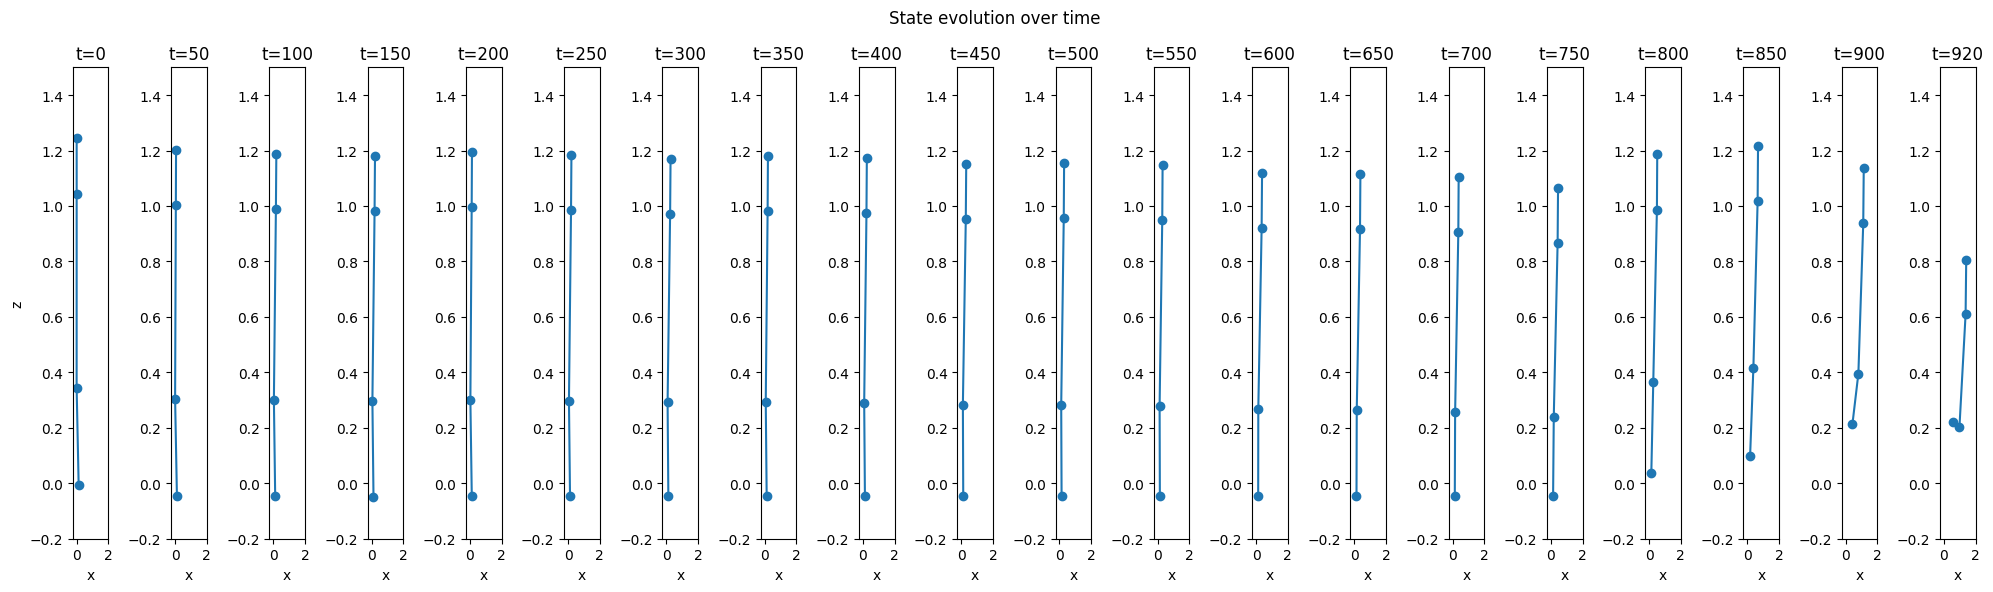

Total reward: 1096.4641


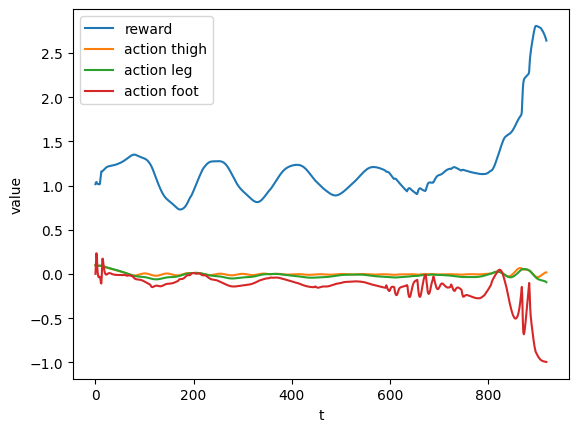

In [ ]:
# Key 0 (fitness = 1096.46)
key = jax.random.PRNGKey(0)
obs, env_state = env.reset(key)
compute_and_visualize(obs, env_state, policy, T)

Timestep 0 : Height: 1.2482982873916626 | x-coordinate thigh: -5.363090895116329e-05 | Thigh angle (rad): 0.0006413438823074102 | 
Timestep 50 : Height: 1.203724980354309 | x-coordinate thigh: 0.0013153497129678726 | Thigh angle (rad): 0.031150491908192635 | 
Timestep 100 : Height: 1.1995441913604736 | x-coordinate thigh: 0.015668407082557678 | Thigh angle (rad): 0.09127753973007202 | 
Timestep 150 : Height: 1.184108018875122 | x-coordinate thigh: 0.0479632169008255 | Thigh angle (rad): 0.14877991378307343 | 
Timestep 200 : Height: 1.184769630432129 | x-coordinate thigh: 0.0528658926486969 | Thigh angle (rad): 0.1329592615365982 | 
Timestep 250 : Height: 1.194148302078247 | x-coordinate thigh: 0.038480475544929504 | Thigh angle (rad): 0.09275107830762863 | 
Timestep 300 : Height: 1.1791414022445679 | x-coordinate thigh: 0.06261947751045227 | Thigh angle (rad): 0.134469136595726 | 
Timestep 350 : Height: 1.1727396249771118 | x-coordinate thigh: 0.0796019434928894 | Thigh angle (rad): 0.

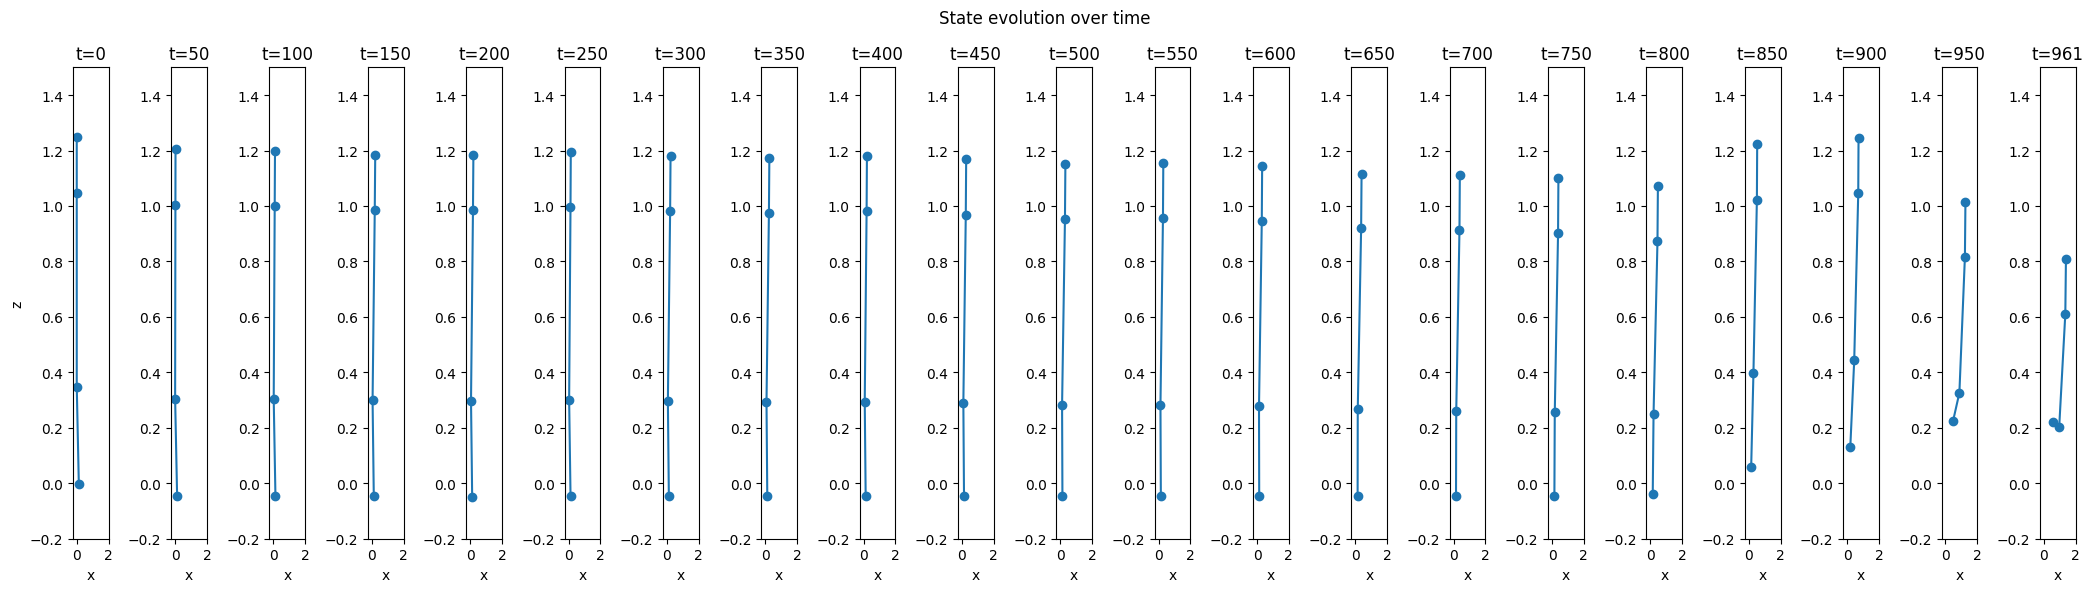

Total reward: 1134.8425


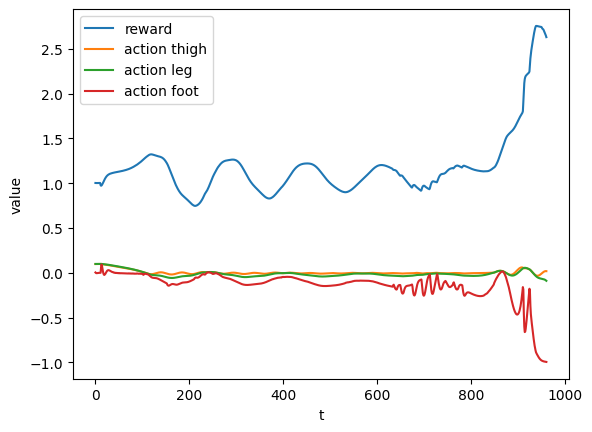

In [ ]:
# Key 26 (fitness = 1134.84)
key = jax.random.PRNGKey(26)
obs, env_state = env.reset(key)
compute_and_visualize(obs, env_state, policy, T)

Timestep 0 : Height: 1.2493358850479126 | x-coordinate thigh: -0.006071852520108223 | Thigh angle (rad): 0.0031257469672709703 | 
Timestep 50 : Height: 1.2037205696105957 | x-coordinate thigh: -0.0059288423508405685 | Thigh angle (rad): 0.031040124595165253 | 
Timestep 100 : Height: 1.1997010707855225 | x-coordinate thigh: 0.007927265018224716 | Thigh angle (rad): 0.08968035876750946 | 
Timestep 150 : Height: 1.1844285726547241 | x-coordinate thigh: 0.039983704686164856 | Thigh angle (rad): 0.14732672274112701 | 
Timestep 200 : Height: 1.1844875812530518 | x-coordinate thigh: 0.04584476351737976 | Thigh angle (rad): 0.13351932168006897 | 
Timestep 250 : Height: 1.1944555044174194 | x-coordinate thigh: 0.030992664396762848 | Thigh angle (rad): 0.0923200398683548 | 
Timestep 300 : Height: 1.1796140670776367 | x-coordinate thigh: 0.05436734855175018 | Thigh angle (rad): 0.13316930830478668 | 
Timestep 350 : Height: 1.1725982427597046 | x-coordinate thigh: 0.07203647494316101 | Thigh angle

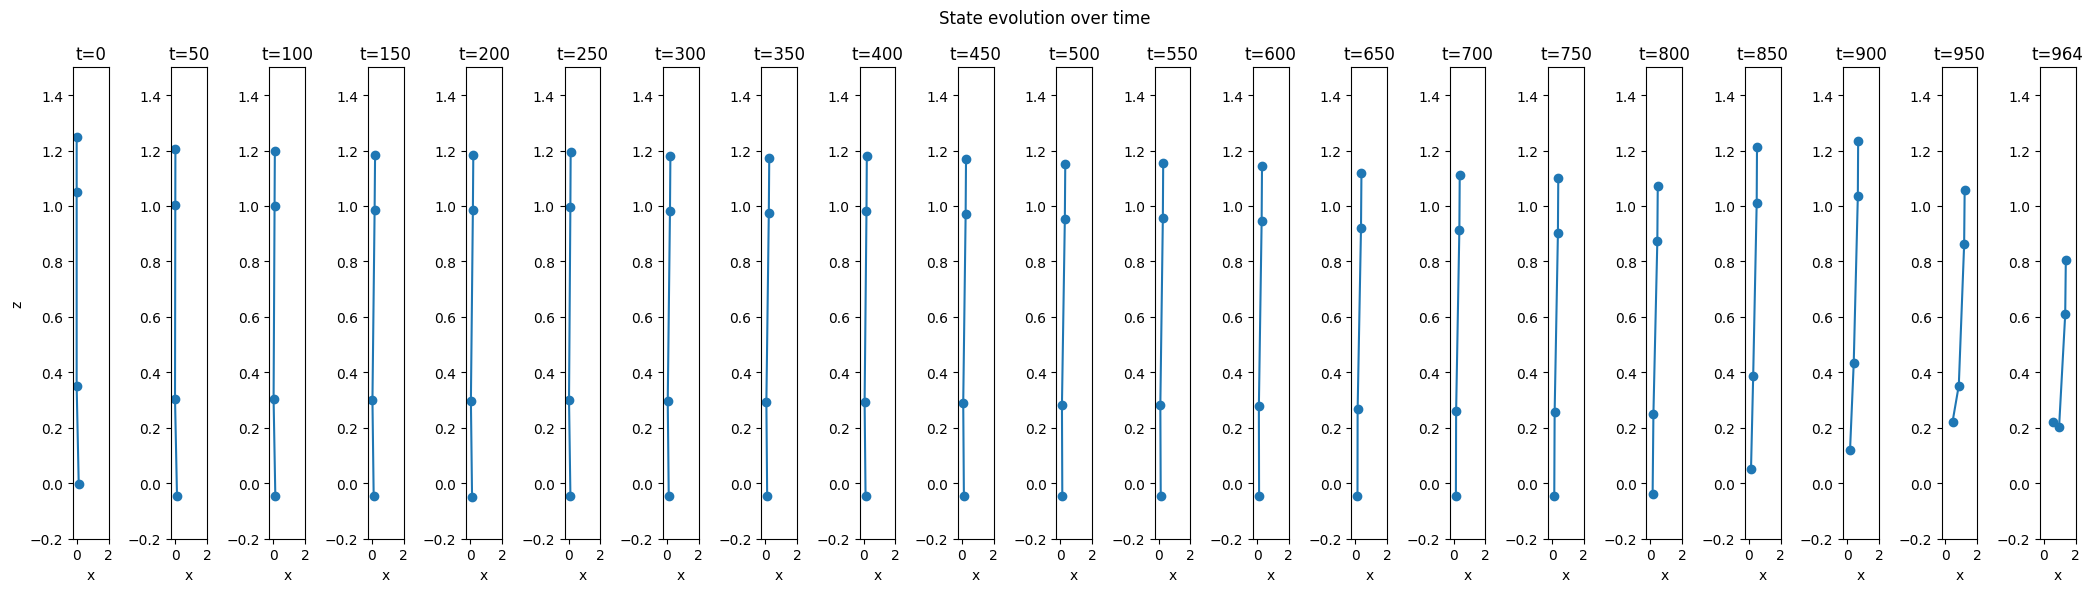

Total reward: 1137.3965


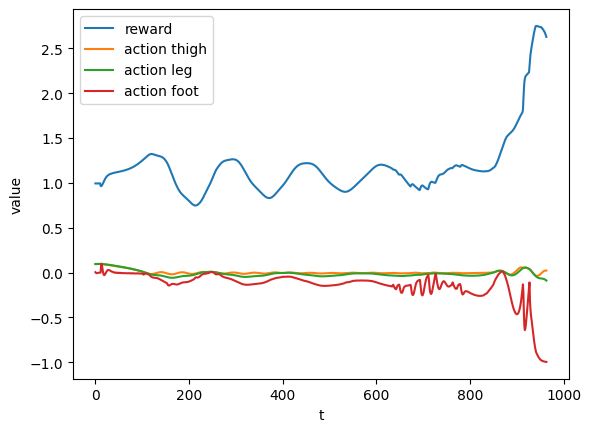

In [ ]:
# Key 10 (fitness = 1137.40)
key = jax.random.PRNGKey(10)
obs, env_state = env.reset(key)
compute_and_visualize(obs, env_state, policy, T)

### Multiple evaluation

In [ ]:
mujoco_env = MujocoGymnaxWrapper('HopperHop')
policy = lambda obs: jnp.array([obs[14]*(obs[5] + obs[7] + obs[8]), 2*obs[10] + obs[13]*obs[8]**2 + 2*obs[14]*(obs[5] + obs[7] + obs[8]) + obs[7] + obs[8], obs[5] + obs[7] + obs[8], 0])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([0, obs[13] + obs[2]*(obs[8] + jnp.sin(obs[1])) + obs[7] + 2*obs[9]*(obs[2]*(obs[8] + jnp.sin(obs[1])) + jnp.sin(obs[1])), obs[2]*(obs[8] + jnp.sin(obs[1])) + obs[8] + 2*jnp.sin(obs[1]), 2*jnp.sin(obs[1])])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

Module mujoco.mjx.third_party.mujoco_warp._src.collision_driver 88f7770 load on device 'cuda:0' took 143.32 ms  (compiled)
Module _nxn_broadphase__locals__kernel_d2d200c6 d2d200c load on device 'cuda:0' took 605.58 ms  (compiled)
Module _primitive_narrowphase__locals__primitive_narrowphase_ca3f8f98 ca3f8f9 load on device 'cuda:0' took 1002.26 ms  (compiled)
Module _efc_contact_init__locals__kernel_703a08a4 703a08a load on device 'cuda:0' took 174.33 ms  (compiled)
Module _efc_contact_jac_dense__locals__kernel_11a6f18c 927acba load on device 'cuda:0' took 1013.46 ms  (compiled)
Module _efc_contact_update__locals__kernel_c77ca81d c77ca81 load on device 'cuda:0' took 661.64 ms  (compiled)
Module _tile_cholesky_factorize_solve__locals__cholesky_factorize_solve_f956cf88 226c0f7 load on device 'cuda:0' took 6133.36 ms  (compiled)
Module solve_init_jaref__locals__kernel_173cbb76 173cbb7 load on device 'cuda:0' took 142.70 ms  (compiled)
Module mul_m_dense__locals___mul_m_dense_d21c2e6d d21c2e

In [ ]:
mujoco_env = MujocoGymnaxWrapper('HopperHop')
policy = lambda obs: jnp.array([0, 4*obs[10] - obs[11]*(obs[9] + jnp.sin(obs[1])) - obs[6]*(2*obs[10] + obs[6] - obs[8]*(obs[10] - obs[11]*(obs[9] + jnp.sin(obs[1])) + obs[7])) + obs[6] + 3*obs[7] - obs[8]*(obs[10] - obs[11]*(obs[9] + jnp.sin(obs[1])) + obs[7]) + jnp.sin(jnp.sin(obs[1])), obs[1] + obs[8] + 2*jnp.sin(obs[1]) + jnp.sin(jnp.sin(obs[1])), 2*obs[10] + obs[6] - obs[8]*(obs[10] - obs[11]*(obs[9] + jnp.sin(obs[1])) + obs[7])])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([3*obs[0] + 0.337*obs[10] + obs[6] + obs[7], obs[0] + 1.34*obs[10] + obs[7], -3*obs[0] - 2.34*obs[10] + obs[3] - obs[6] - 2*obs[7] - 2*obs[8] - 0.337, 5*obs[0] + 8.67*obs[10] + 4*obs[13] + 6*obs[7] + 3*obs[8] + 1.01])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[ 0.     0.    16.17  33.969  0.131  0.     0.     0.     0.     0.   ]
[66.885 40.201 59.113 48.774 39.958 67.912 76.705 29.945 58.86  64.646]


In [ ]:
mujoco_env = MujocoGymnaxWrapper('HopperHop')
policy = lambda obs: jnp.array([obs[11] + obs[3], -obs[11] + obs[2]*obs[5]*jnp.cos(obs[2]) - obs[3], obs[2]*jnp.cos(obs[2]), jnp.cos(obs[2])])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([obs[11] + 2*obs[3] + 0.461, -obs[11] + obs[2]*jnp.cos(obs[2])*jnp.cos(obs[5]) - 2*obs[3] - 0.461, obs[2]*jnp.cos(obs[2])*jnp.cos(obs[5]) + obs[2]*jnp.cos(obs[2]), jnp.cos(obs[2]) + jnp.cos(obs[5])])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

Module mujoco.mjx.third_party.mujoco_warp._src.collision_driver 88f7770 load on device 'cuda:0' took 156.76 ms  (compiled)
Module _nxn_broadphase__locals__kernel_d2d200c6 d2d200c load on device 'cuda:0' took 601.58 ms  (compiled)
Module _primitive_narrowphase__locals__primitive_narrowphase_ca3f8f98 ca3f8f9 load on device 'cuda:0' took 998.57 ms  (compiled)
Module _efc_contact_init__locals__kernel_703a08a4 703a08a load on device 'cuda:0' took 200.11 ms  (compiled)
Module _efc_contact_jac_dense__locals__kernel_11a6f18c 927acba load on device 'cuda:0' took 573.44 ms  (compiled)
Module _efc_contact_update__locals__kernel_c77ca81d c77ca81 load on device 'cuda:0' took 302.27 ms  (compiled)
Module _tile_cholesky_factorize_solve__locals__cholesky_factorize_solve_f956cf88 226c0f7 load on device 'cuda:0' took 4873.45 ms  (compiled)
Module solve_init_jaref__locals__kernel_173cbb76 173cbb7 load on device 'cuda:0' took 147.91 ms  (compiled)
Module mul_m_dense__locals___mul_m_dense_d21c2e6d d21c2e6 

In [ ]:
mujoco_env = MujocoGymnaxWrapper('HopperHop')
policy = lambda obs: jnp.array([3*obs[0]*obs[3]*(obs[13]*obs[6] - obs[14] + obs[7] - obs[8]) + obs[0]*(obs[13]*obs[6] - obs[14] + obs[7] - obs[8]) - 2*obs[0] + 5*obs[10] - obs[14] + obs[3] + obs[7] - obs[8], obs[0]*obs[3]*(obs[13]*obs[6] - obs[14] + obs[7] - obs[8]) + 2*obs[10] + 2*obs[13]*obs[6] - obs[14] + obs[7] - obs[8], obs[0] + obs[14] + obs[3]*(obs[0]*obs[3]*(obs[13]*obs[6] - obs[14] + obs[7] - obs[8]) - obs[0] + 2*obs[10] + obs[3]) + obs[8], obs[0]*(obs[0] + obs[3]*(obs[0]*obs[3]*(obs[13]*obs[6] - obs[14] + obs[7] - obs[8]) - obs[0] + 2*obs[10] + obs[3]))])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([2*obs[10] + 2*obs[12] + 3*obs[13] - 2*obs[14] + 1.74*obs[3] - obs[6] + jnp.sin(obs[2]), obs[10] - obs[11] + obs[12] - obs[14] + 0.871*obs[3] + obs[6] + jnp.sin(jnp.cos(obs[12] + obs[13] + 0.871*obs[3] - obs[6] + jnp.sin(obs[2]))) + jnp.cos(obs[12] + obs[13] + 0.871*obs[3] - obs[6] + jnp.sin(obs[2])), obs[11] + obs[3]*(obs[10] - obs[14] + 2*obs[6]) + jnp.sin(obs[2]) + jnp.sin(jnp.cos(obs[12] + obs[13] + 0.871*obs[3] - obs[6] + jnp.sin(obs[2]))), -2*obs[11] - obs[3]*(obs[10] - obs[14] + 2*obs[6]) + 0.871*obs[3] + jnp.sin(jnp.cos(obs[12] + obs[13] + 0.871*obs[3] - obs[6] + jnp.sin(obs[2])))])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[20.289 13.042 18.417 26.667 38.554 22.976 20.263  8.92  50.861  0.   ]
[ 2.357 63.493 57.156 40.112 40.553 60.129 48.046 47.385 25.538 48.366]


In [ ]:
mujoco_env = MujocoGymnaxWrapper('HopperHop')
policy = lambda obs: jnp.array([obs[0] + obs[10]*obs[8] + obs[8], 3*obs[10] + obs[12], 4*obs[5], obs[10] + obs[3]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([obs[1]*(obs[0] + obs[7]) - obs[11], obs[1]*obs[10] - obs[1]*obs[7], obs[4]**2*(obs[0] + obs[1]), 4*obs[4]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[ 0.     5.91  26.848 12.576  0.062 26.749 15.321 27.939  0.693 15.035]
[ 0.     0.     0.    90.649  0.045  0.     0.     0.     0.     0.   ]


In [ ]:
mujoco_env = MujocoGymnaxWrapper('HopperHop')
policy = lambda obs: jnp.array([obs[4], 2*obs[0] + obs[8]*(obs[8] - obs[9]), 2*obs[1] - obs[2] + obs[5], obs[1] + 2*obs[8]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([obs[2]*(-2.43*obs[2] - 1.43), obs[10]*(obs[10] - 2*obs[12] + 2*obs[4]) + obs[10] - obs[6], 2*obs[1] - obs[2] - obs[6]**2 - obs[6] + obs[8] + 0.626, 2*obs[1] + obs[13] + 3*obs[4]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[ 0.     0.    18.484 54.329  0.041  0.     0.     0.     0.     0.   ]
[ 0.     0.    60.453 50.068  0.118  0.     0.     0.     0.     0.   ]


## Walker2d

Action space: $[-1, 1]^6$, where the first action is the torque applied on the thigh rotor, the second action the torque applied on the leg rotor, the third action the torque applied to the foot rotor, the fourth action is the torque applied on the left thigh rotor, the fifth action the torque applied on the left leg rotor, and the sixth action the torque applied to the left foot rotor.

Observation space: $ℝ^{18}$

0. z-coordinate_top
1. angle_top
2. angle_thigh_joint
3. angle_leg_joint
4. angle_foot_joint
5. angle_left_thigh_joint
6. angle_left_leg_joing
7. angle_left_foot_joint
8. velocity_x-coordinate_top
9. velocity_z-coordinate_top
10. angular_velocity_top
11. angular_velocity_thigh_hinge
12. angular_velocity_leg_hinge
13. angular_velocity_foot_hinge
14. angular_velocity_thigh_hinge
15. angular_velocity_leg_hinge
16. angular_velocity_foot_hinge

The reward consists of three parts:

  - *reward_healthy*:
    +1 for each timepoint that the walker is alive
  - *reward_forward*:
    Reward of walking forward, measured as *(x-coordinate before action - x-coordinate after action) / dt*.
  - *reward_ctrl*:
    Negative reward for penalising the walker if it takes too large actions, measured as *-coefficient **x** sum(action<sup>2</sup>)*.

   The episode terminates when episode duration reaches a 1000 timesteps, when the height of the walker is not in the range [0.7, 2], and the absolute value of the angle is not in the range [-1, 1].

In [ ]:
def protected_divide(x1, x2):
    return jnp.where(x2 == 0, 1.0, x1 / x2)

def safe_power(x, y):
    return jnp.where(
        (x < 0) & (jnp.floor(y) != y),
        1.0,
        jnp.power(x, y)
    )

### Visualize best solution

In [ ]:
env = MujocoGymnaxWrapper("WalkerWalk")
T = 1000

Warp 1.12.1 initialized:
   CUDA Toolkit 12.9, Driver 13.0
   Devices:
     "cpu"      : "x86_64"
     "cuda:0"   : "Tesla T4" (15 GiB, sm_75, mempool enabled)
   Kernel cache:
     /root/.cache/warp/1.12.1
Warp DeprecationWarning: The symbol `warp.types.warp_type_to_np_dtype` will soon be removed from the public API. It can still be accessed from `warp._src.types.warp_type_to_np_dtype` but might be changed or removed without notice.


### Complexity 17, [1-(y1+y0), y7, cos(sin(0.1)), y12-y10, y12-y10, cos(y9)]

In [ ]:
policy = lambda obs: jnp.tanh(jnp.array([1-(obs[1]+obs[0]), obs[7], jnp.cos(jnp.sin(0.1)), obs[12]-obs[10], obs[12]-obs[10], jnp.cos(obs[9])])) # [1-(y1+y0), y7, cos(sin(0.1)), y12-y10, y12-y10, cos(y9)]

1007.94714
Timestep 0 : x-coordinate: -0.005417445208877325 | z-coordinate: -0.005894184112548828 | 
Timestep 50 : x-coordinate: 0.043324630707502365 | z-coordinate: -0.0629071295261383 | 
Timestep 100 : x-coordinate: -0.0233086459338665 | z-coordinate: -0.07060877233743668 | 
Timestep 150 : x-coordinate: -0.280407190322876 | z-coordinate: -0.21566247940063477 | 
Timestep 200 : x-coordinate: -0.5152854323387146 | z-coordinate: -0.38185206055641174 | 
Timestep 250 : x-coordinate: -0.6452203989028931 | z-coordinate: -0.48066163063049316 | 
Timestep 300 : x-coordinate: -0.6653711199760437 | z-coordinate: -0.5215647220611572 | 
Timestep 350 : x-coordinate: -0.5976548194885254 | z-coordinate: -0.5037906765937805 | 
Timestep 400 : x-coordinate: -0.50081467628479 | z-coordinate: -0.4609168469905853 | 
Timestep 450 : x-coordinate: -0.3992319405078888 | z-coordinate: -0.42207327485084534 | 
Timestep 500 : x-coordinate: -0.3235427141189575 | z-coordinate: -0.40627849102020264 | 
Timestep 550 : x

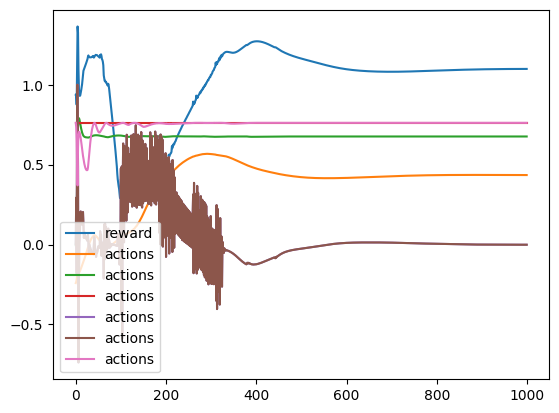

In [ ]:
# Key 0 (fitness = 1007.95)
key = jax.random.PRNGKey(0)
obs, env_state = env.reset(key)
compute_and_visualize(key, obs, env_state, policy, T)

992.7405
Timestep 0 : x-coordinate: -0.0010610377648845315 | z-coordinate: -0.006059050559997559 | 
Timestep 50 : x-coordinate: 0.029043959453701973 | z-coordinate: -0.08344581723213196 | 
Timestep 100 : x-coordinate: -0.014365652576088905 | z-coordinate: -0.11085209250450134 | 
Timestep 150 : x-coordinate: -0.1633824110031128 | z-coordinate: -0.12063881754875183 | 
Timestep 200 : x-coordinate: -0.4154222905635834 | z-coordinate: -0.29886099696159363 | 
Timestep 250 : x-coordinate: -0.6244411468505859 | z-coordinate: -0.42848020792007446 | 
Timestep 300 : x-coordinate: -0.7126945853233337 | z-coordinate: -0.48453664779663086 | 
Timestep 350 : x-coordinate: -0.7171263098716736 | z-coordinate: -0.512783944606781 | 
Timestep 400 : x-coordinate: -0.6542196273803711 | z-coordinate: -0.49577704071998596 | 
Timestep 450 : x-coordinate: -0.5562693476676941 | z-coordinate: -0.4499063789844513 | 
Timestep 500 : x-coordinate: -0.4676890969276428 | z-coordinate: -0.4203586280345917 | 
Timestep 550

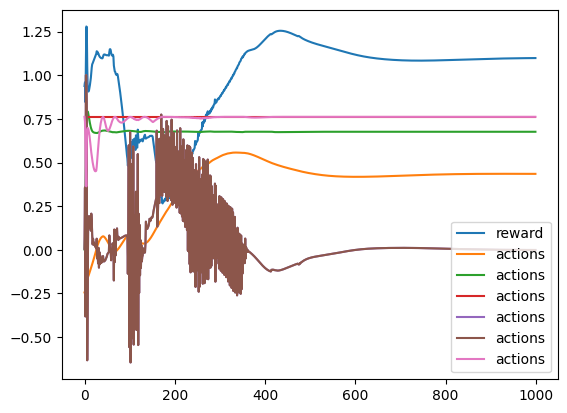

In [ ]:
# Key 26 (fitness = 992.74)
key = jax.random.PRNGKey(26)
obs, env_state = env.reset(key)
compute_and_visualize(key, obs, env_state, policy, T)

972.83704
Timestep 0 : x-coordinate: -0.005208835005760193 | z-coordinate: -0.0036283445078879595 | 
Timestep 50 : x-coordinate: 0.021340755745768547 | z-coordinate: -0.08567746728658676 | 
Timestep 100 : x-coordinate: -0.01856546476483345 | z-coordinate: -0.11766451597213745 | 
Timestep 150 : x-coordinate: -0.12517043948173523 | z-coordinate: -0.12498556822538376 | 
Timestep 200 : x-coordinate: -0.26002204418182373 | z-coordinate: -0.14139513671398163 | 
Timestep 250 : x-coordinate: -0.4812939167022705 | z-coordinate: -0.29726001620292664 | 
Timestep 300 : x-coordinate: -0.6545510292053223 | z-coordinate: -0.41544705629348755 | 
Timestep 350 : x-coordinate: -0.7375612854957581 | z-coordinate: -0.4633634686470032 | 
Timestep 400 : x-coordinate: -0.750730574131012 | z-coordinate: -0.4753968417644501 | 
Timestep 450 : x-coordinate: -0.7163112163543701 | z-coordinate: -0.4649186134338379 | 
Timestep 500 : x-coordinate: -0.6582992076873779 | z-coordinate: -0.44644519686698914 | 
Timestep 5

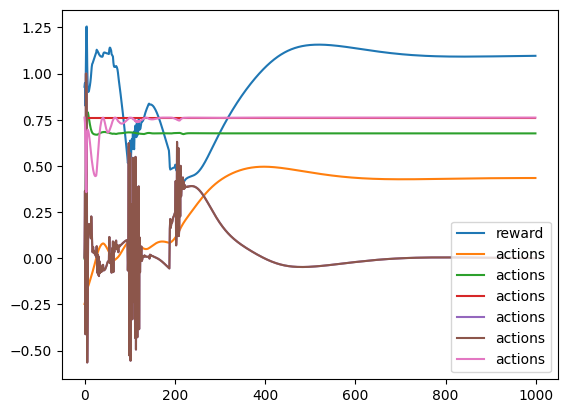

In [ ]:
# Key 10 (fitness = 972.84)
key = jax.random.PRNGKey(10)
obs, env_state = env.reset(key)
compute_and_visualize(key, obs, env_state, policy, T)

### Multiple evaluation

In [ ]:
mujoco_env = MujocoGymnaxWrapper('WalkerWalk')
policy = lambda obs: jnp.array([obs[13] + 2*obs[14] + 2*obs[17] + 2*obs[21] + 6*obs[22] + 2*obs[5], obs[21] + obs[5], obs[14] + obs[17] + obs[21] + obs[22] + obs[5], obs[14] + obs[21] + obs[5], 2*obs[22], obs[17] + obs[22]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([obs[0] + obs[15] + 2*obs[21] + 3*obs[22], obs[17]*(obs[0] + obs[15] + 2*obs[21] + 3*obs[22]), obs[0] + 2*obs[21] + 3*obs[22], obs[0] + obs[21], obs[21] + 2*obs[22], obs[21] + obs[22]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

Module _tile_cholesky_factorize_solve__locals__cholesky_factorize_solve_cdb981f2 c75d2e6 load on device 'cuda:0' took 4184.05 ms  (compiled)
Module solve_init_jaref__locals__kernel_051c9471 051c947 load on device 'cuda:0' took 128.44 ms  (compiled)
Module mul_m_dense__locals___mul_m_dense_86090c8a 86090c8 load on device 'cuda:0' took 270.71 ms  (compiled)
Module update_constraint_gauss_cost__locals__kernel_0aec6e48 0aec6e4 load on device 'cuda:0' took 158.90 ms  (compiled)
Module update_gradient_JTDAJ_dense_tiled__locals__kernel_2b23959a 84da6db load on device 'cuda:0' took 547.99 ms  (compiled)
Module update_gradient_cholesky__locals__kernel_97d1b30b 6b32db2 load on device 'cuda:0' took 4760.48 ms  (compiled)
Module linesearch_iterative__locals__kernel_6962ca73 89f17c9 load on device 'cuda:0' took 1006.02 ms  (compiled)
[126.486 183.672 187.557 159.399 183.04  180.666 209.276 214.563 180.802 209.056]
[288.481 200.324 131.914 173.643 220.211 212.348 231.508 129.078 126.805 232.129]


In [ ]:
mujoco_env = MujocoGymnaxWrapper('WalkerWalk')
policy = lambda obs: jnp.array([2*obs[18] + 2*obs[4], obs[0] + obs[15]*obs[17] - obs[18] + jnp.sin(obs[0] + obs[15]*obs[17] - obs[18] + obs[4]), 0, obs[18] + obs[4], obs[0] - 0.471, obs[0] + obs[15]*obs[17] + 2*(2*obs[18] + 2*obs[4])*(obs[18] + 2*obs[4] + jnp.sin(obs[0] + obs[15]*obs[17] - obs[18] + obs[4])) - 0.471])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([obs[14] + 6*obs[18] + 2*obs[6] - 0.66*jnp.cos(obs[22]), obs[0] - 0.66, jnp.cos(obs[13]) + jnp.cos(obs[22]) + jnp.cos(jnp.cos(obs[4])), obs[0]*obs[18] + obs[18] + jnp.cos(obs[13]) + jnp.cos(jnp.cos(obs[4])), 2*obs[18] + (obs[0] - 0.66)*(obs[0]*obs[18] + obs[18])*(jnp.cos(obs[13]) + jnp.cos(jnp.cos(obs[4])))*(obs[14] + obs[18] + obs[6]) - 0.66*jnp.cos(obs[22]), (obs[0]*obs[18] + obs[18])*(jnp.cos(obs[13]) + jnp.cos(jnp.cos(obs[4])))*(obs[14] + obs[18] + obs[6]) + (obs[0]*obs[18] + obs[18])*(obs[14] + obs[18] + obs[6]) - 0.66*jnp.cos(obs[22])])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[263.505 357.869 263.484 157.828 189.042 315.117 308.894 143.63  235.867 156.382]
[198.04  298.723 305.329 325.068 424.641 316.248 249.18  275.241 188.907 226.276]


In [ ]:
mujoco_env = MujocoGymnaxWrapper('WalkerWalk')
policy = lambda obs: jnp.array([obs[0]*jnp.cos(jnp.cos(obs[14])) + obs[18], 0, obs[0]*jnp.cos(jnp.cos(obs[14])) + 2*jnp.cos(obs[14]) + jnp.cos(jnp.cos(obs[14])), obs[0]*jnp.cos(jnp.cos(obs[14])) + 2*obs[18], obs[19] + jnp.cos(obs[14]), obs[0]*jnp.cos(jnp.cos(obs[14])) + 2*obs[18] + obs[19] + jnp.cos(obs[14])])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([2*obs[18] + obs[9] - 0.321, obs[0] - jnp.cos(obs[0]) + 0.0883, jnp.cos(obs[0]), -obs[0] + obs[18] + obs[9] + jnp.cos(obs[0]) - 0.0883, obs[0] + 0.0883, (obs[18] - 0.321)*(-obs[0] + obs[18] + obs[9] + jnp.cos(obs[0]) - 0.0883)])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

Module _tile_cholesky_factorize_solve__locals__cholesky_factorize_solve_cdb981f2 c75d2e6 load on device 'cuda:0' took 4893.98 ms  (compiled)
Module solve_init_jaref__locals__kernel_051c9471 051c947 load on device 'cuda:0' took 216.04 ms  (compiled)
Module mul_m_dense__locals___mul_m_dense_86090c8a 86090c8 load on device 'cuda:0' took 373.81 ms  (compiled)
Module update_constraint_gauss_cost__locals__kernel_0aec6e48 0aec6e4 load on device 'cuda:0' took 155.49 ms  (compiled)
Module update_gradient_JTDAJ_dense_tiled__locals__kernel_2b23959a 84da6db load on device 'cuda:0' took 576.97 ms  (compiled)
Module update_gradient_cholesky__locals__kernel_97d1b30b 6b32db2 load on device 'cuda:0' took 4077.10 ms  (compiled)
Module linesearch_iterative__locals__kernel_6962ca73 89f17c9 load on device 'cuda:0' took 1108.96 ms  (compiled)
[170.67  213.608 161.395 200.99  183.362 223.379 171.494 195.467 253.588 275.211]
[250.936 221.617 248.403 339.757 245.473 224.669 347.014 204.691 170.449 277.111]


In [ ]:
mujoco_env = MujocoGymnaxWrapper('WalkerWalk')
policy = lambda obs: jnp.array([obs[14]*obs[17] + obs[15] + obs[17] + obs[18], obs[14]*obs[17]*(obs[14]*obs[17] + obs[15] + 2*obs[17] + obs[18] + obs[23] + obs[4] + jnp.cos(obs[0])) + obs[14]*obs[17] + obs[15] + obs[17] + obs[18] + obs[23] + jnp.cos(obs[0]), 2*jnp.cos(obs[0]), obs[14]*obs[17] + 2*obs[14]*obs[20]*jnp.cos(obs[0]) + 2*obs[18], obs[14]*obs[17]*(obs[14]*obs[17] + obs[15] + 2*obs[17] + obs[18] + obs[23] + obs[4] + jnp.cos(obs[0])) + obs[14]*obs[20]*jnp.cos(obs[0]) + obs[18], obs[14]*obs[17] + obs[15] + 2*obs[17] + obs[18] + obs[23] + obs[4] + jnp.cos(obs[0])])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([2*obs[14]*obs[17] + 2*obs[14]*obs[7]*jnp.cos(obs[14]) + obs[14] + obs[17] + 2*obs[18], obs[14]*obs[17]*(obs[17] + obs[2]*(obs[14]*obs[17] + obs[14]*obs[7]*jnp.cos(obs[14]) + obs[14] + obs[17] + obs[18] + obs[7])) + obs[2]*(obs[14]*obs[17] + obs[14]*obs[7]*jnp.cos(obs[14]) + obs[14] + obs[17] + obs[18] + obs[7]), 2*jnp.cos(obs[14]), obs[14]*obs[17] + obs[18] + 2*obs[7]*jnp.cos(obs[14]), obs[14]*obs[17]*(obs[17] + obs[2]*(obs[14]*obs[17] + obs[14]*obs[7]*jnp.cos(obs[14]) + obs[14] + obs[17] + obs[18] + obs[7])) + obs[7]*jnp.cos(obs[14]), obs[17] + obs[2]*(obs[14]*obs[17] + obs[14]*obs[7]*jnp.cos(obs[14]) + obs[14] + obs[17] + obs[18] + obs[7])])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[245.304 207.691 219.615 192.182 219.883 264.863 175.034 309.933 191.54  183.667]
[313.472 305.015 259.529 214.351 272.758 325.753 217.206 184.324 240.17  227.501]


In [ ]:
mujoco_env = MujocoGymnaxWrapper('WalkerWalk')
policy = lambda obs: jnp.array([3*obs[18], obs[14] - 0.752, obs[14], 2*obs[18] + jnp.cos(obs[17]), obs[0] + obs[8]*(obs[12] - obs[8]), obs[20]*(obs[12] + 2*obs[20])])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([obs[0] + obs[21], obs[0] + obs[1] + obs[6] - 1.24, jnp.cos(jnp.cos(jnp.cos(jnp.sin(2*obs[12])))), 4*obs[21], 2*obs[0] + obs[3], 2*obs[17] + obs[22] + obs[6]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

Module mujoco.mjx.warp.ffi 98d2031 load on device 'cuda:0' took 535.67 ms  (compiled)
Module mujoco.mjx.third_party.mujoco_warp._src.smooth 95a0b8b load on device 'cuda:0' took 7292.67 ms  (compiled)
Module mujoco.mjx.third_party.mujoco_warp._src.collision_driver 88f7770 load on device 'cuda:0' took 147.59 ms  (compiled)
Module _nxn_broadphase__locals__kernel_d2d200c6 d2d200c load on device 'cuda:0' took 609.80 ms  (compiled)
Module _primitive_narrowphase__locals__primitive_narrowphase_304f8b71 304f8b7 load on device 'cuda:0' took 590.46 ms  (compiled)
Module mujoco.mjx.third_party.mujoco_warp._src.constraint 981fdaf load on device 'cuda:0' took 4034.42 ms  (compiled)
Module _efc_contact_init__locals__kernel_703a08a4 703a08a load on device 'cuda:0' took 190.17 ms  (compiled)
Module _efc_contact_jac_dense__locals__kernel_11a6f18c 927acba load on device 'cuda:0' took 956.69 ms  (compiled)
Module _efc_contact_update__locals__kernel_c77ca81d c77ca81 load on device 'cuda:0' took 302.26 ms  

In [ ]:
mujoco_env = MujocoGymnaxWrapper('WalkerWalk')
policy = lambda obs: jnp.array([obs[15] + 2*obs[18] + obs[21], obs[9]*(-0.799*obs[19] - 0.799*obs[21]), obs[1] + obs[15], 2*obs[18] + jnp.cos(obs[14]), obs[1]*obs[10]*obs[17]**2, obs[11] + obs[14] + obs[5]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([3*obs[18] - 0.455, obs[10] - obs[13] - obs[19] + obs[22], 2*obs[17], obs[18], obs[0] + obs[14] - 2*obs[8], 2*obs[20]**2])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[196.236 264.117 171.896 235.519 227.078 303.047 241.112 295.991 208.661 248.115]
[370.126 191.43  302.05  340.486 186.792 191.479 265.477 181.137 273.084 215.512]


## Half cheetah

Action space: $[-1, 1]^6$, where the first action is the torque applied on the back thigh rotor, the second action the torque applied on the back shin rotor, the third action the torque applied to the back foot rotor, the fourth action is the torque applied on the front thigh rotor, the fifth action the torque applied on the front shin rotor, and the sixth action the torque applied to the front foot rotor.

Observation space: $ℝ^{18}$

0. z-coordinate_mass
1. w-orientation_front_tip
2. y-orientation_front_tip
3. angle_back_thigh_rotor
4. angle_back_shin_rotor
5. angle_back_foot_rotor
6. velocity_tip_along_y-axis
7. angular_velocity_front_tip
8. angular_velocity_second_rotor
9. x-coordinate_front_tip
10. y-coordinate_front_tip
11. angle_front_tip
12. angle_second_rotor
13. angle_second_rotor
14. velocity_tip_along_x-axis
15. velocity_tip_along_y-axis
16. angular_velocity_front_tip
17. angular_velocity_second_rotor

The reward consists of two parts:

  - *reward_run*: A reward of moving forward which is measured as (x-coordinate before action - x-coordinate after action) / dt.
  
  - *reward_ctrl*: A negative reward for penalising too large actions. Measured as *-coefficient x sum(action<sup>2</sup>)*


   The episode terminates when episode duration reaches a 1000 timesteps.

### Visualize best solution

In [ ]:
env = MujocoGymnaxWrapper("CheetahRun")
# env = EpisodeWrapper(envs.get_environment(env_name="halfcheetah"), episode_length=1000, action_repeat=1)
T = 1000

### Complexity 12, equation: [y12, y4, y12-(y5-y7), y9-y12, y11, y4]

In [ ]:
policy = lambda obs: jnp.tanh(jnp.array([obs[12], obs[4], obs[12]-(obs[5]-obs[7]), obs[9]-obs[12], obs[11], obs[4]])) #[y12, y4, y12-(y5-y7), y9-y12, y11, y4]

2978.4678
Timestep 0 : x-coordinate: -0.08178076148033142 | z-coordinate: -0.095660001039505 | 
Timestep 50 : x-coordinate: 2.38871431350708 | z-coordinate: -0.09221171587705612 | 
Timestep 100 : x-coordinate: 8.621200561523438 | z-coordinate: -0.06894395500421524 | 
Timestep 150 : x-coordinate: 16.67304229736328 | z-coordinate: -0.10898301005363464 | 
Timestep 200 : x-coordinate: 25.30753517150879 | z-coordinate: -0.09262372553348541 | 
Timestep 250 : x-coordinate: 34.08720779418945 | z-coordinate: -0.1010054349899292 | 
Timestep 300 : x-coordinate: 43.17593765258789 | z-coordinate: -0.10532348603010178 | 
Timestep 350 : x-coordinate: 52.46951675415039 | z-coordinate: -0.10018076747655869 | 
Timestep 400 : x-coordinate: 61.65583419799805 | z-coordinate: -0.10891806334257126 | 
Timestep 450 : x-coordinate: 70.73224639892578 | z-coordinate: -0.09733713418245316 | 
Timestep 500 : x-coordinate: 80.06959533691406 | z-coordinate: -0.07779885828495026 | 
Timestep 550 : x-coordinate: 88.83036

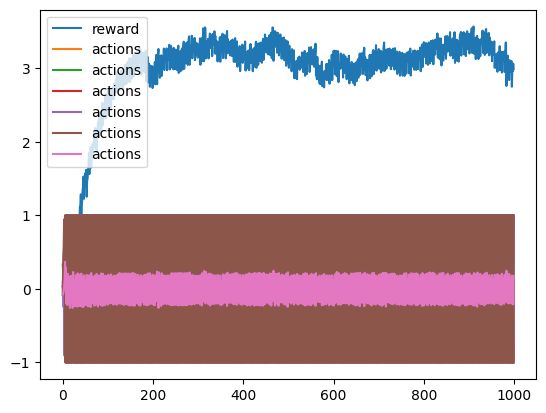

In [ ]:
# Key 0 (fitness = 2978.47)
key = jax.random.PRNGKey(0)
obs, env_state = env.reset(key)
compute_and_visualize(key, obs, env_state, policy, T)

2972.193
Timestep 0 : x-coordinate: -0.005560265388339758 | z-coordinate: -0.03917696699500084 | 
Timestep 50 : x-coordinate: 2.959642171859741 | z-coordinate: -0.05954207107424736 | 
Timestep 100 : x-coordinate: 9.80587100982666 | z-coordinate: -0.09707234054803848 | 
Timestep 150 : x-coordinate: 18.025623321533203 | z-coordinate: -0.07687520980834961 | 
Timestep 200 : x-coordinate: 26.49812126159668 | z-coordinate: -0.10363573580980301 | 
Timestep 250 : x-coordinate: 35.31904602050781 | z-coordinate: -0.08660735189914703 | 
Timestep 300 : x-coordinate: 44.3740119934082 | z-coordinate: -0.10125432163476944 | 
Timestep 350 : x-coordinate: 53.5367317199707 | z-coordinate: -0.09650392830371857 | 
Timestep 400 : x-coordinate: 62.5969352722168 | z-coordinate: -0.05754129961133003 | 
Timestep 450 : x-coordinate: 70.94964599609375 | z-coordinate: -0.07853036373853683 | 
Timestep 500 : x-coordinate: 79.75067138671875 | z-coordinate: -0.09249204397201538 | 
Timestep 550 : x-coordinate: 88.7348

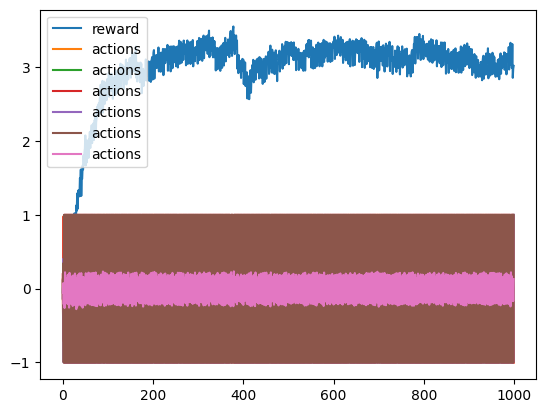

In [ ]:
# Key 26 (fitness = 2972.19)
key = jax.random.PRNGKey(26)
obs, env_state = env.reset(key)
compute_and_visualize(key, obs, env_state, policy, T)

2984.4453
Timestep 0 : x-coordinate: -0.10491332411766052 | z-coordinate: -0.026704953983426094 | 
Timestep 50 : x-coordinate: 2.3813424110412598 | z-coordinate: -0.10811687260866165 | 
Timestep 100 : x-coordinate: 8.77885627746582 | z-coordinate: -0.09327013045549393 | 
Timestep 150 : x-coordinate: 17.077999114990234 | z-coordinate: -0.08826549351215363 | 
Timestep 200 : x-coordinate: 25.58230209350586 | z-coordinate: -0.09927700459957123 | 
Timestep 250 : x-coordinate: 34.34417724609375 | z-coordinate: -0.07795645296573639 | 
Timestep 300 : x-coordinate: 43.26480484008789 | z-coordinate: -0.08044816553592682 | 
Timestep 350 : x-coordinate: 52.41455841064453 | z-coordinate: -0.07467088848352432 | 
Timestep 400 : x-coordinate: 61.56828689575195 | z-coordinate: -0.10805187374353409 | 
Timestep 450 : x-coordinate: 70.95648193359375 | z-coordinate: -0.09586606174707413 | 
Timestep 500 : x-coordinate: 79.96334838867188 | z-coordinate: -0.09857287257909775 | 
Timestep 550 : x-coordinate: 88

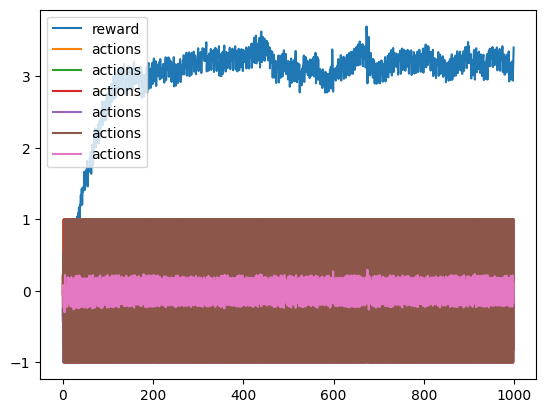

In [ ]:
# Key 10 (fitness = 2984.45)
key = jax.random.PRNGKey(10)
obs, env_state = env.reset(key)
compute_and_visualize(key, obs, env_state, policy, T)

### Multiple evaluation

In [ ]:
mujoco_env = MujocoGymnaxWrapper('CheetahRun')
policy = lambda obs: jnp.array([-2*obs[1] + 5*obs[11] + 3*obs[12] + 3*obs[14] + 2*obs[15] + 3*obs[9], 0, 2*obs[11] + obs[15] + obs[9], 0, 0, 0])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([2*obs[1] + 4*obs[11]*obs[3] + 4*obs[11] + obs[12] + 2*obs[9], 0, 2*obs[11]*obs[3] + obs[11], 0, 0, 0])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[183.892 212.466 234.023 230.9   225.17  206.525 197.757 162.738 203.516 214.619]
[219.562 206.748 228.983 200.124 243.859 213.264 229.229 218.033 237.127 241.216]


In [ ]:
mujoco_env = MujocoGymnaxWrapper('CheetahRun')
policy = lambda obs: jnp.array([obs[1]*obs[6]*obs[9]*(obs[10]*obs[12] + obs[9] + jnp.sin(obs[9])) + obs[10]*obs[12] + 3*obs[11] + 3*obs[3] + 2*obs[7] + 2*jnp.sin(obs[9]) + 2*jnp.sin(jnp.sin(obs[9])), 0, obs[11] + obs[3] + obs[7] - 2*obs[9] + jnp.sin(jnp.sin(obs[9])), obs[1]*obs[9], 0, 0])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([1.0*obs[16]*obs[9] + 4.0*obs[16] + obs[3] + 2*obs[5], 0, obs[10]*(obs[1] - 1.22) + obs[11] - obs[13] - obs[16]*obs[9] + obs[5], 0, -0.606*obs[11] + 0.606*obs[16]*obs[9] - 0.606*obs[16], 0])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[221.18  216.778 229.119 205.306 237.611 242.436 218.511 215.571 231.423 218.89 ]
[305.318 308.952 319.917 287.012 303.031 301.408 306.77  278.236 248.745 281.466]


In [ ]:
mujoco_env = MujocoGymnaxWrapper('CheetahRun')
policy = lambda obs: jnp.array([-obs[11]*obs[9] + obs[11] + obs[9] + 0.0158, 0, -obs[11]*obs[9] + obs[11], 0, obs[11]*obs[9], 0])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([-obs[11]*obs[9] + 2*obs[11] + 2*obs[2]*(obs[11]*obs[9] - obs[11]) + obs[9], 0, -obs[11]*obs[9] + obs[11], 0, obs[11]*obs[9] - obs[11] - obs[2]*(obs[11]*obs[9] - obs[11]) + obs[6], 0])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[228.029 256.997 203.092 234.249 263.274 256.94  238.235 224.349 275.157 225.923]
[301.389 241.676 289.312 332.105 353.94  257.773 307.596 294.534 301.709 271.37 ]


In [ ]:
mujoco_env = MujocoGymnaxWrapper('CheetahRun')
policy = lambda obs: jnp.array([3*obs[0]*obs[11]*(0.226*obs[11] + 0.679*obs[6]) + 5*obs[0] + 8*obs[11] + obs[15] + 22*obs[6], 0, obs[0]*obs[11]*(0.226*obs[11] + 0.679*obs[6]) + 0.226*obs[11] + 0.679*obs[6], 0, obs[0]*(0.226*obs[11] + 0.679*obs[6]), 0])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([2*obs[0]*obs[1]*obs[11]*(0.226*obs[11] + 0.226*obs[4] + 0.453*obs[6]) + 3*obs[11] + 2*obs[14] + 3*obs[4] + 3*obs[6] + 10*obs[9], 0, obs[0]*obs[11]*(0.226*obs[11] + 0.226*obs[4] + 0.453*obs[6]) + 0.226*obs[11] + 0.226*obs[4] + 0.453*obs[6], 0, obs[0]*(0.226*obs[11] + 0.226*obs[4] + 0.453*obs[6]) + obs[5]*(obs[0]*obs[1]*obs[11]*(0.226*obs[11] + 0.226*obs[4] + 0.453*obs[6]) + obs[14] + 5*obs[9]), 0])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[250.895 242.993 233.569 258.957 239.762 242.009 260.126 235.152 251.82  217.735]
[301.231 266.225 298.726 297.263 310.567 288.431 321.088  76.496 295.538 319.157]


In [ ]:
mujoco_env = MujocoGymnaxWrapper('CheetahRun')
policy = lambda obs: jnp.array([obs[11] + obs[12] + 2*obs[9], 2*obs[2] - obs[4] - 1.24, obs[10] + obs[11]*obs[8] + obs[6], obs[0]*obs[10]*obs[8] - obs[8], obs[12]*(obs[12] + obs[3]*obs[8]), jnp.cos(jnp.cos(jnp.cos(obs[5])))])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([obs[1] + obs[11] - 2*obs[12], obs[12]*obs[2]*obs[5]**2, obs[11] + 3*obs[2], obs[0]*obs[4]*obs[8]**2, -0.588*obs[11] - 0.588*obs[13], -obs[5] + obs[6]])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[248.783 216.976 272.458 258.199 282.693 259.001 122.627 269.086 277.081 263.4  ]
[259.398 254.43  258.64  315.501 270.054 286.314 147.135 268.161 296.289 267.976]


In [ ]:
mujoco_env = MujocoGymnaxWrapper('CheetahRun')
policy = lambda obs: jnp.array([(obs[11] + jnp.cos(obs[11]))*jnp.cos(obs[5]), obs[2]**3*obs[5], obs[11]*obs[2] + obs[11] - obs[2], 0, -obs[1] + obs[3]*obs[8] + obs[3], obs[10] + jnp.cos(jnp.cos(jnp.cos(obs[6])))])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

policy = lambda obs: jnp.array([-obs[0] - 2*obs[12] + obs[16], jnp.cos(jnp.cos(jnp.cos(jnp.cos(jnp.cos(jnp.cos(obs[4])))))), obs[10] + 3*obs[11], 0.334*obs[4] + 0.112, obs[12], jnp.cos(jnp.cos(3*obs[7]))])
key = jr.PRNGKey(0)
reward_list_inv_pen = repeated_evaluation(key, policy, mujoco_env)
print(reward_list_inv_pen)

[ 75.204 197.118 251.852 123.404 269.859 219.779 208.463  73.154 314.192 150.233]
[242.613 291.792 285.128 186.131 276.268 298.913 284.85  257.823 278.618 296.769]
